In [1]:
from pathlib import Path
from pypdf import PdfReader

# 현재 위치(notebooks)의 한 단계 위가 프로젝트 폴더입니다.
project_root = Path.cwd().parent

# 프로젝트 폴더 안의 data 폴더에서 PDF를 찾습니다.
pdf_path = project_root / "data" / "santafe_hev_manual.pdf"

# 경로가 맞는지 먼저 확인합니다.
print(f"찾는 위치: {pdf_path}")
print(f"파일이 있나요?: {pdf_path.exists()}")

찾는 위치: c:\mle-02-p1-team1\data\santafe_hev_manual.pdf
파일이 있나요?: True


In [2]:
from pypdf import PdfReader

# 확인한 경로의 PDF를 엽니다.
reader = PdfReader(str(pdf_path))

# PDF에 들어 있는 전체 페이지 수를 출력합니다.
print(f"전체 페이지 수: {len(reader.pages)}")

# 파이썬은 페이지를 0부터 세므로 [0]은 첫 페이지입니다.
first_page_text = reader.pages[0].extract_text() or ""

# 첫 페이지에서 추출한 글자 수와 앞부분을 확인합니다.
print(f"첫 페이지 글자 수: {len(first_page_text)}자")
print("\n[첫 페이지 글자 앞부분]")
print(first_page_text[:500])

전체 페이지 수: 779
첫 페이지 글자 수: 414자

[첫 페이지 글자 앞부분]
안전 및 차량 손상 경고
본 취급설명서에는 고객 및 차량의 안전을 위해 유의해야 할 사항과 제품 사용에 대한 정확한 정보
를 알리는 안전경고 표시가 포함되어 있습니다. 지시사항을 반드시 숙지하고 준수하십시오.
경고, 주의표시 경고, 주의가 있는 문장 및 진하게 표시되어 있는 부분은 특히 유념하
십시오.
҃Ҋ 
부상이나 사망의 우려가 있는 경우를 나타내는 표시입니다.
 ઱੄ 
차량이 고장나거나 손상될 우려가 있는 경우를 나타내는 표시입니다.
ӝ 
차량 용어 설명 또는 추가 설명을 나타내는 표시입니다.
안전을 위해 반드시 지켜야 하는 사항을 나타내는 표시입니다.
선택 또는 미장착
사양표시
본 취급설명서에는 모든 트림모델 및 선택 사양을 포함하여 설명하고
있습니다.
고객님의 차량에 장착되지 않는 사양에 대한 설명이 포함될 수 있습
니다.


In [3]:
from statistics import mean, median

# 페이지 번호와 추출된 글자 수를 기록합니다.
page_lengths = []

for page_number, page in enumerate(reader.pages, start=1):
    page_text = page.extract_text() or ""
    page_lengths.append((page_number, len(page_text)))

# 글자가 전혀 없는 페이지와 100자 미만인 페이지를 찾습니다.
empty_pages = [number for number, length in page_lengths if length == 0]
short_pages = [number for number, length in page_lengths if length < 100]

print(f"페이지 수: {len(page_lengths)}")
print(f"글자가 없는 페이지 수: {len(empty_pages)}")
print(f"100자 미만 페이지 수: {len(short_pages)}")
print(f"평균 글자 수: {mean(length for _, length in page_lengths):.1f}")
print(f"중간 글자 수: {median(length for _, length in page_lengths):.1f}")
print(f"글자가 없는 페이지 번호: {empty_pages[:20]}")
print(f"100자 미만 페이지 번호 일부: {short_pages[:20]}")

페이지 수: 779
글자가 없는 페이지 수: 2
100자 미만 페이지 수: 26
평균 글자 수: 763.4
중간 글자 수: 593.0
글자가 없는 페이지 번호: [4, 6]
100자 미만 페이지 번호 일부: [2, 4, 6, 28, 32, 44, 46, 47, 69, 182, 371, 378, 435, 460, 464, 469, 609, 699, 714, 721]


In [4]:
# 글자가 100자 미만인 페이지마다 내장 이미지 수를 확인합니다.
for page_number in short_pages:
    page = reader.pages[page_number - 1]
    page_text = page.extract_text() or ""
    images = page.images

    print(
        f"페이지 {page_number}: "
        f"글자 {len(page_text)}자, "
        f"이미지 {len(images)}개"
    )

페이지 2: 글자 92자, 이미지 3개
페이지 4: 글자 0자, 이미지 0개
페이지 6: 글자 0자, 이미지 0개
페이지 28: 글자 17자, 이미지 0개
페이지 32: 글자 19자, 이미지 0개
페이지 44: 글자 75자, 이미지 2개
페이지 46: 글자 99자, 이미지 1개
페이지 47: 글자 80자, 이미지 1개
페이지 69: 글자 20자, 이미지 1개
페이지 182: 글자 8자, 이미지 0개
페이지 371: 글자 61자, 이미지 0개
페이지 378: 글자 9자, 이미지 0개
페이지 435: 글자 80자, 이미지 0개
페이지 460: 글자 11자, 이미지 0개
페이지 464: 글자 83자, 이미지 0개
페이지 469: 글자 96자, 이미지 1개
페이지 609: 글자 98자, 이미지 0개
페이지 699: 글자 46자, 이미지 0개
페이지 714: 글자 81자, 이미지 0개
페이지 721: 글자 41자, 이미지 1개
페이지 741: 글자 89자, 이미지 2개
페이지 743: 글자 95자, 이미지 0개
페이지 749: 글자 86자, 이미지 3개
페이지 750: 글자 84자, 이미지 1개
페이지 764: 글자 9자, 이미지 0개
페이지 765: 글자 7자, 이미지 0개


이미지 1: 686 × 473 픽셀


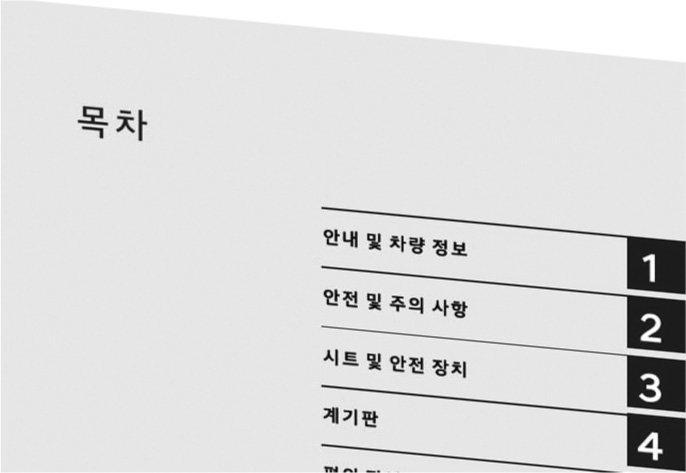

이미지 2: 686 × 473 픽셀


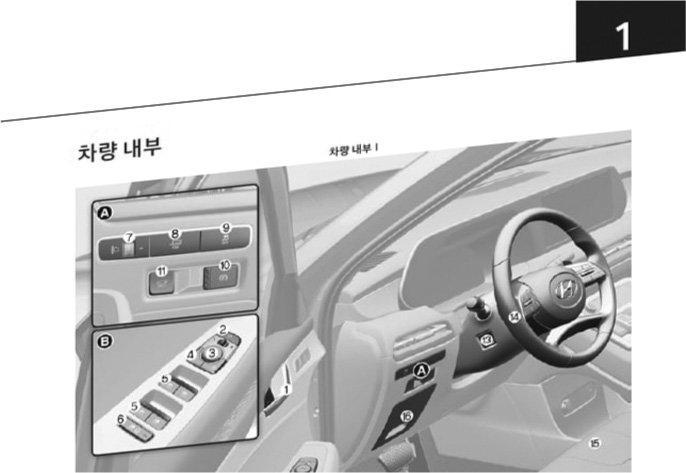

이미지 3: 686 × 473 픽셀


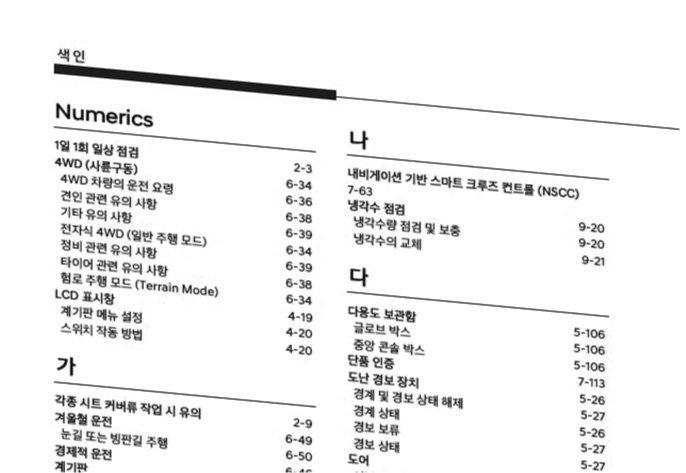

In [5]:
from IPython.display import display

# 사람이 세는 2페이지는 파이썬에서는 인덱스 1입니다.
page_2 = reader.pages[1]

# 2페이지에서 추출된 이미지를 차례로 화면에 표시합니다.
for image_number, image in enumerate(page_2.images, start=1):
    print(f"이미지 {image_number}: {image.image.size[0]} × {image.image.size[1]} 픽셀")
    display(image.image)

PDF 44페이지 글자:
온도에 따른 엔진 오일 SAE 점도 분류표
SAE 점도와 사용 온도 범위
온도 (℃)
1.6 T-GDi HEV
안내 및 차량 정보
39
이미지 1: 945 × 71 픽셀


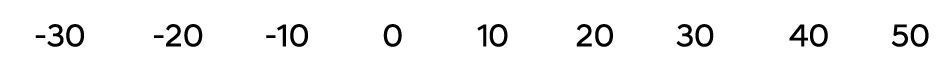

이미지 2: 945 × 71 픽셀


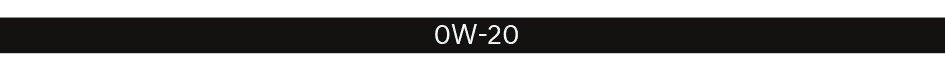

In [6]:
from IPython.display import display

# PDF의 44페이지를 선택합니다. 파이썬 인덱스는 0부터 시작합니다.
page_number = 44
page = reader.pages[page_number - 1]

# 그림과 함께 있는 설명 글자를 확인합니다.
page_text = page.extract_text() or ""
print(f"PDF {page_number}페이지 글자:")
print(page_text[:500])

# 페이지에 들어 있는 이미지를 차례로 표시합니다.
for image_number, image in enumerate(page.images, start=1):
    print(f"이미지 {image_number}: {image.image.size[0]} × {image.image.size[1]} 픽셀")
    display(image.image)

In [7]:
# PDF의 44페이지에 있는 SAE 점도 표 정보를 한 묶음으로 정리합니다.
pdf_page_number = 44
manual_page_number = 39  # 원본 PDF 아래쪽에 인쇄된 페이지 번호

page = reader.pages[pdf_page_number - 1]

table_record = {
    "pdf_page_number": pdf_page_number,
    "manual_page_number": manual_page_number,
    "heading": "온도에 따른 엔진 오일 SAE 점도 분류표",
    "context_text": page.extract_text() or "",
    "image_parts": [
        {
            "name": image.name,
            "size": image.image.size,
        }
        for image in page.images
    ],
}

# 이미지 두 조각이 같은 표와 페이지에 연결됐는지 확인합니다.
print("PDF 페이지:", table_record["pdf_page_number"])
print("매뉴얼 페이지:", table_record["manual_page_number"])
print("표 이미지 조각:", len(table_record["image_parts"]))
print("이미지 정보:", table_record["image_parts"])

PDF 페이지: 44
매뉴얼 페이지: 39
표 이미지 조각: 2
이미지 정보: [{'name': 'I1.jpg', 'size': (945, 71)}, {'name': 'I2.jpg', 'size': (945, 71)}]


In [8]:
# 이미지에서 확인한 내용을 설명 문장으로 기록합니다.
table_record["image_description"] = (
    "온도 눈금은 -30도부터 50도까지 표시되어 있다. "
    "1.6 T-GDi HEV 행에 0W-20이 표시되어 있다."
)

# 표 제목, PDF에서 추출한 글자, 이미지 설명을 하나의 검색 문장으로 합칩니다.
table_record["search_text"] = "\n".join(
    part
    for part in [
        table_record["heading"],
        table_record["context_text"],
        table_record["image_description"],
    ]
    if part.strip()
)

# 검색에 사용될 문장의 앞부분을 확인합니다.
print(table_record["search_text"][:700])

온도에 따른 엔진 오일 SAE 점도 분류표
온도에 따른 엔진 오일 SAE 점도 분류표
SAE 점도와 사용 온도 범위
온도 (℃)
1.6 T-GDi HEV
안내 및 차량 정보
39
온도 눈금은 -30도부터 50도까지 표시되어 있다. 1.6 T-GDi HEV 행에 0W-20이 표시되어 있다.


In [9]:
# PDF에서 읽은 글자에는 표 제목이 이미 포함되어 있습니다.
# 그래서 제목을 다시 붙이지 않고 이미지 설명만 이어 붙입니다.
table_record["search_text"] = "\n".join(
    part.strip()
    for part in [
        table_record["context_text"],
        table_record["image_description"],
    ]
    if part.strip()
)

print(table_record["search_text"][:700])

온도에 따른 엔진 오일 SAE 점도 분류표
SAE 점도와 사용 온도 범위
온도 (℃)
1.6 T-GDi HEV
안내 및 차량 정보
39
온도 눈금은 -30도부터 50도까지 표시되어 있다. 1.6 T-GDi HEV 행에 0W-20이 표시되어 있다.


In [10]:
# 검색할 글자와 출처 정보, 이미지 조각 정보를 한 묶음으로 정리합니다.
search_record = {
    "content": table_record["search_text"],
    "metadata": {
        "pdf_page_number": table_record["pdf_page_number"],
        "manual_page_number": table_record["manual_page_number"],
        "content_type": "table_with_images",
    },
    "image_parts": table_record["image_parts"],
}

# 각 정보가 제대로 묶였는지 간단히 확인합니다.
print("검색할 글자:", search_record["content"][:300])
print("출처 정보:", search_record["metadata"])
print("이미지 조각:", search_record["image_parts"])

검색할 글자: 온도에 따른 엔진 오일 SAE 점도 분류표
SAE 점도와 사용 온도 범위
온도 (℃)
1.6 T-GDi HEV
안내 및 차량 정보
39
온도 눈금은 -30도부터 50도까지 표시되어 있다. 1.6 T-GDi HEV 행에 0W-20이 표시되어 있다.
출처 정보: {'pdf_page_number': 44, 'manual_page_number': 39, 'content_type': 'table_with_images'}
이미지 조각: [{'name': 'I1.jpg', 'size': (945, 71)}, {'name': 'I2.jpg', 'size': (945, 71)}]


In [11]:
# PDF 글자를 한 페이지 단위로 묶습니다.
page_chunks = []

for pdf_page_number, page in enumerate(reader.pages, start=1):
    page_text = (page.extract_text() or "").strip()

    # 글자가 없는 페이지는 검색용 자료에서 제외합니다.
    if not page_text:
        continue

    page_chunks.append({
        "content": page_text,
        "pdf_page_number": pdf_page_number,
    })

print(f"글자 청크 수: {len(page_chunks)}")

# SAE 점도 표가 있는 44페이지 청크도 확인합니다.
page_44_chunk = next(
    chunk for chunk in page_chunks
    if chunk["pdf_page_number"] == 44
)
print("44페이지 글자 앞부분:", page_44_chunk["content"][:200])

글자 청크 수: 777
44페이지 글자 앞부분: 온도에 따른 엔진 오일 SAE 점도 분류표
SAE 점도와 사용 온도 범위
온도 (℃)
1.6 T-GDi HEV
안내 및 차량 정보
39


In [12]:
# 주변 3페이지의 첫 부분과 끝 부분을 비교합니다.
for pdf_page_number in [43, 44, 45]:
    page_text = reader.pages[pdf_page_number - 1].extract_text() or ""
    lines = [
        line.strip()
        for line in page_text.splitlines()
        if line.strip()
    ]

    print(f"\nPDF {pdf_page_number}페이지")
    print("처음 3줄:", lines[:3])
    print("마지막 3줄:", lines[-3:])


PDF 43페이지
처음 3줄: ['추천 오일 및 용량', '종류 용량 추천 사양', '연료 67 ℓ 무연 휘발유']
마지막 3줄: ['•', '•', '•']

PDF 44페이지
처음 3줄: ['온도에 따른 엔진 오일 SAE 점도 분류표', 'SAE 점도와 사용 온도 범위', '온도 (℃)']
마지막 3줄: ['1.6 T-GDi HEV', '안내 및 차량 정보', '39']

PDF 45페이지
처음 3줄: ['차대번호 (VIN)', '2C_VINPosition', '차대번호(VIN: Vehicle Identification Number)는 차량 등록, 차량 소유권 유지 등 모든 법적']
마지막 3줄: ['엔진과 차량 실내 사이의 차체 패널에 타각되어 있습니다.', '1', '40']


차대번호 (VIN)
2C_VINPosition
차대번호(VIN: Vehicle Identification Number)는 차량 등록, 차량 소유권 유지 등 모든 법적
인 사항에 사용되는 차량의 고유 번호입니다.
차체에 타각된 차대번호와 차량 등록증에 기록된 차대번호는 일치해야 합니다.
엔진과 차량 실내 사이의 차체 패널에 타각되어 있습니다.
1
40
이미지 1: I1.jpg, 크기 (688, 440)


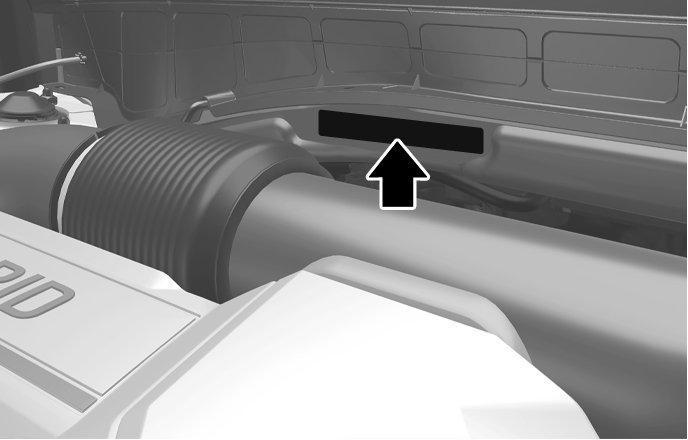

In [13]:
from IPython.display import display

# PDF 45페이지를 선택합니다. 파이썬 인덱스는 0부터 시작합니다.
pdf_page_number = 45
page = reader.pages[pdf_page_number - 1]

# 페이지 글자와 포함된 이미지를 확인합니다.
print((page.extract_text() or "")[:300])

for image_number, image in enumerate(page.images, start=1):
    print(f"이미지 {image_number}: {image.name}, 크기 {image.image.size}")
    display(image.image)

In [14]:
# PDF 45페이지의 글자와 그림을 가져옵니다.
vin_pdf_page = 45
vin_manual_page = 40
vin_page = reader.pages[vin_pdf_page - 1]

# 이미지 이름처럼 보이는 표시를 본문에서 제외합니다.
vin_text = (vin_page.extract_text() or "").replace("2C_VINPosition", "").strip()

# PDF 설명과 그림을 함께 검색할 수 있도록 그림 설명을 덧붙입니다.
vin_image_description = (
    "그림의 화살표는 엔진과 차량 실내 사이 차체 패널에 있는 "
    "차대번호 타각 위치를 가리킨다."
)

# 글자·페이지 출처·이미지 정보를 한 자료로 묶습니다.
vin_record = {
    "content": f"{vin_text}\n{vin_image_description}",
    "metadata": {
        "pdf_page_number": vin_pdf_page,
        "manual_page_number": vin_manual_page,
        "content_type": "figure_with_text",
    },
    "image_parts": [
        {
            "name": image.name,
            "size": image.image.size,
        }
        for image in vin_page.images
    ],
}

print("출처:", vin_record["metadata"])
print("이미지:", vin_record["image_parts"])
print("검색할 글자:", vin_record["content"][:400])

출처: {'pdf_page_number': 45, 'manual_page_number': 40, 'content_type': 'figure_with_text'}
이미지: [{'name': 'I1.jpg', 'size': (688, 440)}]
검색할 글자: 차대번호 (VIN)

차대번호(VIN: Vehicle Identification Number)는 차량 등록, 차량 소유권 유지 등 모든 법적
인 사항에 사용되는 차량의 고유 번호입니다.
차체에 타각된 차대번호와 차량 등록증에 기록된 차대번호는 일치해야 합니다.
엔진과 차량 실내 사이의 차체 패널에 타각되어 있습니다.
1
40
그림의 화살표는 엔진과 차량 실내 사이 차체 패널에 있는 차대번호 타각 위치를 가리킨다.


In [15]:
# PDF에서 추출한 원본 글자는 그대로 보관합니다.
raw_vin_text = vin_page.extract_text() or ""

# 검색할 때 방해되는 이미지 이름만 검색용 글자에서 제외합니다.
vin_search_text = raw_vin_text.replace("2C_VINPosition", "").strip()

# 그림에서 확인한 설명을 검색용 글자에 붙입니다.
vin_search_text = f"{vin_search_text}\n{vin_image_description}".strip()

vin_record["raw_text"] = raw_vin_text
vin_record["search_text"] = vin_search_text

print("원본에는 이미지 이름이 남아 있나요?:", "2C_VINPosition" in vin_record["raw_text"])
print("검색용 글자에 이미지 이름이 있나요?:", "2C_VINPosition" in vin_record["search_text"])
print(vin_record["search_text"][:400])

원본에는 이미지 이름이 남아 있나요?: True
검색용 글자에 이미지 이름이 있나요?: False
차대번호 (VIN)

차대번호(VIN: Vehicle Identification Number)는 차량 등록, 차량 소유권 유지 등 모든 법적
인 사항에 사용되는 차량의 고유 번호입니다.
차체에 타각된 차대번호와 차량 등록증에 기록된 차대번호는 일치해야 합니다.
엔진과 차량 실내 사이의 차체 패널에 타각되어 있습니다.
1
40
그림의 화살표는 엔진과 차량 실내 사이 차체 패널에 있는 차대번호 타각 위치를 가리킨다.


In [16]:
# 차대번호 페이지 기록에 어떤 항목이 있는지 확인합니다.
print("기록 항목:", list(vin_record.keys()))

기록 항목: ['content', 'metadata', 'image_parts', 'raw_text', 'search_text']


In [17]:
# 세 가지 글자 항목이 서로 어떻게 다른지 짧게 확인합니다.
for name in ("content", "raw_text", "search_text"):
    value = vin_record.get(name, "")
    print(f"\n{name}: {type(value).__name__}, 글자 수={len(value) if isinstance(value, str) else '-'}")

    if isinstance(value, str):
        print(value[:120].replace("\n", " "))

# 페이지 출처와 이미지 개수도 확인합니다.
print("\n출처 정보:", vin_record.get("metadata"))
print("이미지 개수:", len(vin_record.get("image_parts", [])))


content: str, 글자 수=232
차대번호 (VIN)  차대번호(VIN: Vehicle Identification Number)는 차량 등록, 차량 소유권 유지 등 모든 법적 인 사항에 사용되는 차량의 고유 번호입니다. 차체에 타각된 차대번호와 차량

raw_text: str, 글자 수=196
차대번호 (VIN) 2C_VINPosition 차대번호(VIN: Vehicle Identification Number)는 차량 등록, 차량 소유권 유지 등 모든 법적 인 사항에 사용되는 차량의 고유 번호입니다. 차체

search_text: str, 글자 수=232
차대번호 (VIN)  차대번호(VIN: Vehicle Identification Number)는 차량 등록, 차량 소유권 유지 등 모든 법적 인 사항에 사용되는 차량의 고유 번호입니다. 차체에 타각된 차대번호와 차량

출처 정보: {'pdf_page_number': 45, 'manual_page_number': 40, 'content_type': 'figure_with_text'}
이미지 개수: 1


In [18]:
# 두 항목의 전체 내용이 정말 같은지 확인합니다.
print("content와 search_text가 완전히 같나요?:", vin_record["content"] == vin_record["search_text"])

content와 search_text가 완전히 같나요?: True


In [19]:
from pathlib import Path

# 노트북 코드가 어느 폴더를 기준으로 실행되는지 확인합니다.
current_folder = Path.cwd()
print(f"현재 작업 폴더: {current_folder}")

# 현재 폴더 아래의 data 폴더에서 싼타페 PDF를 찾습니다.
pdf_path = current_folder / "data" / "santafe_hev_manual.pdf"
print(f"찾아볼 파일: {pdf_path}")
print(f"파일이 있나요?: {pdf_path.exists()}")

현재 작업 폴더: c:\mle-02-p1-team1\notebooks
찾아볼 파일: c:\mle-02-p1-team1\notebooks\data\santafe_hev_manual.pdf
파일이 있나요?: False


In [20]:
from pathlib import Path

# 현재 폴더(notebooks)의 상위 폴더를 프로젝트 폴더로 봅니다.
project_folder = Path.cwd().parent

# 프로젝트 폴더 아래 data 폴더에서 PDF를 찾습니다.
pdf_path = project_folder / "data" / "santafe_hev_manual.pdf"

print("찾는 위치:", pdf_path)
print("파일이 있나요?:", pdf_path.exists())

찾는 위치: c:\mle-02-p1-team1\data\santafe_hev_manual.pdf
파일이 있나요?: True


In [21]:
# 이미지마다 어떤 정보가 기록되어 있는지 확인합니다.
for 번호, 이미지 in enumerate(vin_record["image_parts"], start=1):
    print(f"\n이미지 {번호} 자료형:", type(이미지).__name__)

    # 이미지 정보가 딕셔너리라면 항목 이름을 확인합니다.
    if isinstance(이미지, dict):
        print("기록된 항목:", list(이미지.keys()))

        # 파일 이름이나 크기처럼 확인에 필요한 정보만 출력합니다.
        for 항목 in ("name", "filename", "path", "size", "width", "height"):
            if 항목 in 이미지:
                print(f"{항목}:", 이미지[항목])


이미지 1 자료형: dict
기록된 항목: ['name', 'size']
name: I1.jpg
size: (688, 440)


In [22]:
# 이미지가 이미 저장되어 있는지 프로젝트의 data와 notebooks 폴더에서 찾습니다.
search_folders = [
    project_folder / "data",
    project_folder / "notebooks",
]

found_images = []

for folder in search_folders:
    if folder.exists():
        found_images.extend(folder.rglob("I1.jpg"))

print("찾은 I1.jpg 파일 수:", len(found_images))

for image_path in found_images:
    print(image_path)

찾은 I1.jpg 파일 수: 2
c:\mle-02-p1-team1\data\zzong_santafe_lag\images\pdf_page_44\I1.jpg
c:\mle-02-p1-team1\data\zzong_santafe_lag\images\pdf_page_45\I1.jpg


In [23]:
from pathlib import Path
from pypdf import PdfReader

# 노트북 폴더에서 실행 중이면 한 단계 위를 프로젝트 폴더로 사용합니다.
현재_폴더 = Path.cwd()
프로젝트_폴더 = (
    현재_폴더.parent
    if 현재_폴더.name.lower() == "notebooks"
    else 현재_폴더
)

# 원본 PDF 파일을 엽니다.
pdf_path = 프로젝트_폴더 / "data" / "santafe_hev_manual.pdf"
reader = PdfReader(str(pdf_path))

# PDF 45쪽은 파이썬에서 0부터 세므로 44번 위치입니다.
pdf_페이지_번호 = 45
페이지 = reader.pages[pdf_페이지_번호 - 1]
이미지들 = 페이지.images

# 승인한 개인 작업 폴더를 준비합니다.
저장_폴더 = (
    프로젝트_폴더
    / "data"
    / "zzong_santafe_lag"
    / "images"
    / "pdf_page_45"
)
저장_폴더.mkdir(parents=True, exist_ok=True)

# 페이지 안의 이미지를 I1.jpg 같은 이름으로 저장합니다.
for 번호, 이미지 in enumerate(이미지들, start=1):
    확장자 = Path(이미지.name).suffix.lower() or ".png"
    저장_경로 = 저장_폴더 / f"I{번호}{확장자}"

    if 저장_경로.exists():
        print("이미 있어 건너뜀:", 저장_경로)
    else:
        이미지.image.save(저장_경로)
        print("저장 완료:", 저장_경로, "| 이미지 크기:", 이미지.image.size)

print("PDF 45쪽 이미지 개수:", len(이미지들))

이미 있어 건너뜀: c:\mle-02-p1-team1\data\zzong_santafe_lag\images\pdf_page_45\I1.jpg
PDF 45쪽 이미지 개수: 1


In [24]:
from pathlib import Path

# 현재 위치에서 프로젝트 폴더를 찾습니다.
현재_폴더 = Path.cwd()
프로젝트_폴더 = (
    현재_폴더.parent
    if 현재_폴더.name.lower() == "notebooks"
    else 현재_폴더
)

# 저장한 이미지 파일의 경로를 만듭니다.
이미지_경로 = (
    프로젝트_폴더
    / "data"
    / "zzong_santafe_lag"
    / "images"
    / "pdf_page_45"
    / "I1.jpg"
)

# 이미지 파일이 있는지 확인한 뒤 기록에 경로를 연결합니다.
if not 이미지_경로.exists():
    raise FileNotFoundError(f"이미지 파일을 찾을 수 없습니다: {이미지_경로}")

vin_record["image_parts"][0]["local_path"] = (
    이미지_경로.relative_to(프로젝트_폴더).as_posix()
)

print("이미지 연결 경로:", vin_record["image_parts"][0]["local_path"])

이미지 연결 경로: data/zzong_santafe_lag/images/pdf_page_45/I1.jpg


In [25]:
from pathlib import Path
from pypdf import PdfReader

# 노트북 폴더에서 실행하면 한 단계 위를 프로젝트 폴더로 사용합니다.
현재_폴더 = Path.cwd()
프로젝트_폴더 = (
    현재_폴더.parent
    if 현재_폴더.name.lower() == "notebooks"
    else 현재_폴더
)

# 산타페 설명서 PDF를 엽니다.
pdf_path = 프로젝트_폴더 / "data" / "santafe_hev_manual.pdf"
reader = PdfReader(str(pdf_path))

# PDF 44쪽은 파이썬에서 0부터 세므로 43번 위치입니다.
pdf_페이지_번호 = 44
페이지 = reader.pages[pdf_페이지_번호 - 1]
이미지들 = 페이지.images

# 예상한 이미지 2개가 맞는지 먼저 확인합니다.
print("PDF 44쪽 이미지 개수:", len(이미지들))

if len(이미지들) != 2:
    raise ValueError("PDF 44쪽 이미지가 예상한 2개가 아닙니다. 결과를 확인해 주세요.")

# 승인한 개인 폴더를 준비합니다.
저장_폴더 = (
    프로젝트_폴더
    / "data"
    / "zzong_santafe_lag"
    / "images"
    / "pdf_page_44"
)
저장_폴더.mkdir(parents=True, exist_ok=True)

# 표를 이루는 이미지 두 조각을 I1, I2 이름으로 저장합니다.
for 번호, 이미지 in enumerate(이미지들, start=1):
    확장자 = Path(이미지.name).suffix.lower() or ".png"
    저장_경로 = 저장_폴더 / f"I{번호}{확장자}"

    if 저장_경로.exists():
        print("이미 있어 건너뜀:", 저장_경로)
    else:
        이미지.image.save(저장_경로)
        print(
            "저장 완료:",
            저장_경로,
            "| 이미지 크기:",
            이미지.image.size,
        )

PDF 44쪽 이미지 개수: 2
이미 있어 건너뜀: c:\mle-02-p1-team1\data\zzong_santafe_lag\images\pdf_page_44\I1.jpg
이미 있어 건너뜀: c:\mle-02-p1-team1\data\zzong_santafe_lag\images\pdf_page_44\I2.jpg


In [26]:
# 노트북에 만들어 둔 record 변수의 이름만 확인합니다.
print([이름 for 이름 in globals() if "record" in 이름.lower()])

['table_record', 'search_record', 'vin_record']


In [27]:
# PDF 44쪽 표 기록이 어느 변수인지 출처와 글자 앞부분으로 확인합니다.
for 변수_이름 in ("table_record", "search_record"):
    기록 = globals()[변수_이름]

    print(f"\n변수 이름: {변수_이름}")
    print("출처 정보:", 기록.get("metadata"))
    print("글자 앞부분:", 기록.get("content", "")[:80])


변수 이름: table_record
출처 정보: None
글자 앞부분: 

변수 이름: search_record
출처 정보: {'pdf_page_number': 44, 'manual_page_number': 39, 'content_type': 'table_with_images'}
글자 앞부분: 온도에 따른 엔진 오일 SAE 점도 분류표
SAE 점도와 사용 온도 범위
온도 (℃)
1.6 T-GDi HEV
안내 및 차량 정보
39
온도 눈


In [28]:
from pathlib import Path

# 프로젝트 폴더와 PDF 44쪽 이미지 폴더를 찾습니다.
현재_폴더 = Path.cwd()
프로젝트_폴더 = (
    현재_폴더.parent
    if 현재_폴더.name.lower() == "notebooks"
    else 현재_폴더
)
이미지_폴더 = (
    프로젝트_폴더
    / "data"
    / "zzong_santafe_lag"
    / "images"
    / "pdf_page_44"
)

# PDF 44쪽 기록에 이미지가 2개인지 확인합니다.
이미지_기록들 = search_record["image_parts"]

if len(이미지_기록들) != 2:
    raise ValueError("search_record의 이미지 개수가 예상한 2개와 다릅니다.")

# 이미지 이름에 해당하는 파일을 찾아 경로를 기록합니다.
for 이미지_기록 in 이미지_기록들:
    이미지_이름 = Path(이미지_기록["name"]).name
    이미지_경로 = 이미지_폴더 / 이미지_이름

    if not 이미지_경로.exists():
        raise FileNotFoundError(f"이미지 파일을 찾을 수 없습니다: {이미지_경로}")

    이미지_기록["local_path"] = (
        이미지_경로.relative_to(프로젝트_폴더).as_posix()
    )

# 연결 결과를 확인합니다.
for 이미지_기록 in 이미지_기록들:
    print(이미지_기록)

{'name': 'I1.jpg', 'size': (945, 71), 'local_path': 'data/zzong_santafe_lag/images/pdf_page_44/I1.jpg'}
{'name': 'I2.jpg', 'size': (945, 71), 'local_path': 'data/zzong_santafe_lag/images/pdf_page_44/I2.jpg'}


In [29]:
# PDF 44쪽 표와 PDF 45쪽 차대번호 기록의 항목 구성을 비교합니다.
for 설명, 기록 in (
    ("PDF 44쪽 표", search_record),
    ("PDF 45쪽 차대번호", vin_record),
):
    print(f"\n{설명}")
    print("기록 항목:", list(기록.keys()))
    print("출처 정보:", 기록.get("metadata"))
    print("이미지 개수:", len(기록.get("image_parts", [])))


PDF 44쪽 표
기록 항목: ['content', 'metadata', 'image_parts']
출처 정보: {'pdf_page_number': 44, 'manual_page_number': 39, 'content_type': 'table_with_images'}
이미지 개수: 2

PDF 45쪽 차대번호
기록 항목: ['content', 'metadata', 'image_parts', 'raw_text', 'search_text']
출처 정보: {'pdf_page_number': 45, 'manual_page_number': 40, 'content_type': 'figure_with_text'}
이미지 개수: 1


In [30]:
# PDF 44쪽에서 가공하지 않은 원문을 다시 읽습니다.
pdf44_raw_text = reader.pages[43].extract_text() or ""

# 기존 기록을 덮어쓰지 않도록, 정리할 대상과 원문을 새 목록에 담습니다.
정리_대상 = [
    ("PDF 44쪽 표", search_record, pdf44_raw_text),
    ("PDF 45쪽 차대번호", vin_record, vin_record.get("raw_text", "")),
]

# 공통 항목(content, raw_text, metadata, image_parts)을 가진 새 기록을 만듭니다.
normalized_records = []

for 설명, 기존_기록, 원문 in 정리_대상:
    새_기록 = {
        "content": 기존_기록["content"],
        "raw_text": 원문,
        "metadata": dict(기존_기록["metadata"]),
        # 이미지 정보도 복사해 원래 기록과 서로 영향을 주지 않게 합니다.
        "image_parts": [
            dict(이미지_정보)
            for 이미지_정보 in 기존_기록.get("image_parts", [])
        ],
    }
    normalized_records.append(새_기록)

# 새 정리본에 필요한 항목이 들어갔는지 간단히 확인합니다.
for 설명, 기록 in zip(
    ("PDF 44쪽 표", "PDF 45쪽 차대번호"),
    normalized_records,
):
    print(f"\n{설명}")
    print("기록 항목:", list(기록.keys()))
    print("PDF 쪽수:", 기록["metadata"]["pdf_page_number"])
    print("원문 글자 수:", len(기록["raw_text"]))
    print("검색용 글자 수:", len(기록["content"]))
    print("이미지 경로:", [
        이미지.get("local_path")
        for 이미지 in 기록["image_parts"]
    ])


PDF 44쪽 표
기록 항목: ['content', 'raw_text', 'metadata', 'image_parts']
PDF 쪽수: 44
원문 글자 수: 75
검색용 글자 수: 137
이미지 경로: ['data/zzong_santafe_lag/images/pdf_page_44/I1.jpg', 'data/zzong_santafe_lag/images/pdf_page_44/I2.jpg']

PDF 45쪽 차대번호
기록 항목: ['content', 'raw_text', 'metadata', 'image_parts']
PDF 쪽수: 45
원문 글자 수: 196
검색용 글자 수: 232
이미지 경로: ['data/zzong_santafe_lag/images/pdf_page_45/I1.jpg']


In [31]:
from statistics import mean, median

# PDF 각 페이지에서 글자를 읽고, 페이지 번호와 글자 수만 기록합니다.
페이지별_글자수 = []

for 페이지_번호, 페이지 in enumerate(reader.pages, start=1):
    원문 = 페이지.extract_text() or ""
    글자수 = len(원문.strip())

    if 글자수 > 0:
        페이지별_글자수.append((페이지_번호, 글자수))

# 글자 수가 많은 순서로 정렬합니다.
긴_페이지_순서 = sorted(
    페이지별_글자수,
    key=lambda 항목: 항목[1],
    reverse=True,
)

print("PDF 전체 페이지 수:", len(reader.pages))
print("글자가 있는 페이지 수:", len(페이지별_글자수))
print("평균 글자 수:", round(mean(글자수 for _, 글자수 in 페이지별_글자수), 1))
print("중앙 글자 수:", median(글자수 for _, 글자수 in 페이지별_글자수))
print("가장 긴 페이지 10개:", 긴_페이지_순서[:10])

PDF 전체 페이지 수: 779
글자가 있는 페이지 수: 777
평균 글자 수: 765.3
중앙 글자 수: 595
가장 긴 페이지 10개: [(771, 5128), (769, 5105), (770, 5052), (778, 5007), (773, 5000), (774, 4929), (775, 4917), (772, 4903), (768, 4894), (776, 4883)]


In [32]:
# 글자 수가 가장 많았던 페이지들의 앞뒤 내용을 짧게 확인합니다.
for 페이지_번호, 글자수 in sorted(긴_페이지_순서[:10]):
    원문 = reader.pages[페이지_번호 - 1].extract_text() or ""

    print(f"\nPDF {페이지_번호}쪽 | 글자 수: {글자수}")
    print("앞부분:", 원문[:180].replace("\n", " "))
    print("끝부분:", 원문[-100:].replace("\n", " "))


PDF 768쪽 | 글자 수: 4894
앞부분: 벨트                                                                                                                                                711 하이브리드 스타트 & 제너레이터(HSG) 구동 벨트 점
끝부분:               271 색인 763 • - • - • - - • - - - - - - - • - - • - - - • - • - • • - - - • - - - • - -

PDF 769쪽 | 글자 수: 5105
앞부분: 스마트 테일게이트 작동 방법                                                                                                  270 스마트 회생 시스템                                                     
끝부분:              309 I 764 - • - - - - - - - • - - - - - - • - - - - - • • • - - - - - - - - - - - - • -

PDF 770쪽 | 글자 수: 5052
앞부분: 뒷좌석 퍼스널 램프                                                                                                                  309 무드 램프                                               
끝부분:               131 색인 765 - - - - - - - • - - • - - - - - - - • - - - • - - - - • - • - - • - • • - -

PDF 771쪽 | 글자 수: 5128
앞부분: 승객 구분 시스템 (OCS)            

In [33]:
# 색인 앞뒤의 페이지를 확인해 색인 구간을 찾습니다.
for 페이지_번호 in range(767, 780):
    원문 = (reader.pages[페이지_번호 - 1].extract_text() or "").strip()
    한줄_원문 = 원문.replace("\n", " ")

    print(
        f"PDF {페이지_번호}쪽 | 글자 수: {len(원문)}"
        f" | 앞부분: {한줄_원문[:100]}"
        f" | 끝부분: {한줄_원문[-70:]}"
    )

PDF 767쪽 | 글자 수: 4796 | 앞부분: 경계 상태                                                                                                | 끝부분:  - • - - - - - - • • - - - - - - • - - • - - • • • - - - • - - • - - -
PDF 768쪽 | 글자 수: 4894 | 앞부분: 벨트                                                                                                   | 끝부분:  - • - - • - - - - - - - • - - • - - - • - • - • • - - - • - - - • - -
PDF 769쪽 | 글자 수: 5105 | 앞부분: 스마트 테일게이트 작동 방법                                                                                      | 끝부분:  - - - - - • - - - - - - • - - - - - • • • - - - - - - - - - - - - • -
PDF 770쪽 | 글자 수: 5052 | 앞부분: 뒷좌석 퍼스널 램프                                                                                           | 끝부분:  - - - - • - - • - - - - - - - • - - - • - - - - • - • - - • - • • - -
PDF 771쪽 | 글자 수: 5128 | 앞부분: 승객 구분 시스템 (OCS)                                                                                      | 끝부분:  - - - - - - • - • • - • • • - 

In [34]:
# 색인 바로 앞 페이지가 본문인지 확인합니다.
페이지_번호 = 766
원문 = (reader.pages[페이지_번호 - 1].extract_text() or "").strip()

print("PDF 쪽수:", 페이지_번호)
print("글자 수:", len(원문))
print("앞부분:", 원문[:250].replace("\n", " "))
print("끝부분:", 원문[-120:].replace("\n", " "))


PDF 쪽수: 766
글자 수: 4506
앞부분: 가 각종 시트 커버류 작업 시 유의                                                                                                      55 겨울철 운전                                                                                                                        
끝부분:                                         223 색인 761 • • - • • - - - • - - • • • • - - - • - - • - - - - - - - • - - • • -


In [35]:
# 색인이 시작되는 PDF 쪽수를 찾기 위해 앞선 페이지를 확인합니다.
for 페이지_번호 in range(761, 766):
    원문 = (reader.pages[페이지_번호 - 1].extract_text() or "").strip()
    한줄_원문 = 원문.replace("\n", " ")

    print(
        f"\nPDF {페이지_번호}쪽 | 글자 수: {len(원문)}"
        f" | 앞부분: {한줄_원문[:150]}"
        f" | 끝부분: {한줄_원문[-80:]}"
    )


PDF 761쪽 | 글자 수: 472 | 앞부분: 배기가스 저감을 위한 차량 관리 유해 배기가스는 차량의 정비 상태, 특히 엔진 상태의 양호 여부에 직접적인 영향을 받습니다. 차 량의 생산 또는 검사 과정에서 완전하게 조정됐더라도 주행 정도에 따라 엔진의 상태가 변화되어 유해 가스 배출량이 증가될 수 있습니다. 이를  | 끝부분: 내리막길을 내려오며 시동 걸기를 하지 마십시오. 외부 기온이 높을 때 저속 엔진으로 장시간 가동하길 삼가십시오. 9 756 • • • • • •

PDF 762쪽 | 글자 수: 983 | 앞부분: 배기가스 제어 장치의 관리 및 정비 배기가스 제어 관련 부품 중 다음의 항목은 정기 점검 주기표에 따라 점검하거나 교체하십시오. 점화 플러그 점화 플러그에 이상이 생기면 불완전연소로 인한 엔진 부조 현상, 유해 배기가스 증가 등이 나타납 니다. 정기 주기표에 따라 점검 | 끝부분: 운전하거나 성능이 다 된 촉매 장치로 운전하지 말고 철저한 정기 점검 및 교체를 하십시오. 정기 점검 757 • • • • • • • • • •

PDF 763쪽 | 글자 수: 503 | 앞부분: 엔진이나 배기제어 시스템의 어떤 부품도 개조 하거나 함부로 변경하지 마십시오.  ઱੄  위의 사항이 지켜지지 않으면 촉매 변환 장치와 차량이 손상될 수 있고, 이로 인한 보증을 받지 못 할 수 있습니다. ҃Ҋ  쉽게 연소되는 물체(잔디, 낙엽, 종이, 카펫, 기름 등) | 끝부분: 과다 발생은 정비 명령이나 고발의 대상이 되며, 배기 파이프의 고열과 고압으로 인해 화재나 사고가 날 수 있습니다. 9 758 • • • • •

PDF 764쪽 | 글자 수: 9 | 앞부분: 정기 점검 759 | 끝부분: 정기 점검 759

PDF 765쪽 | 글자 수: 7 | 앞부분: I. 색인 I | 끝부분: I. 색인 I


In [36]:
# PDF 764쪽에 추출할 수 있는 이미지가 있는지 확인합니다.
페이지_764 = reader.pages[763]

print("PDF 764쪽 추출 글자:", repr(페이지_764.extract_text() or ""))
print("PDF 764쪽 이미지 개수:", len(페이지_764.images))


PDF 764쪽 추출 글자: '정기 점검\n759'
PDF 764쪽 이미지 개수: 0


In [37]:
# PDF 1~763쪽에서 이미지가 들어 있는 페이지와 이미지 개수를 확인합니다.
이미지_페이지_목록 = []

for 페이지_번호 in range(1, 764):
    페이지_이미지들 = reader.pages[페이지_번호 - 1].images

    if len(페이지_이미지들) > 0:
        이미지_페이지_목록.append((페이지_번호, len(페이지_이미지들)))

print("이미지가 있는 페이지 수:", len(이미지_페이지_목록))
print("이미지 총 개수:", sum(개수 for _, 개수 in 이미지_페이지_목록))
print("이미지 페이지 목록 앞부분:", 이미지_페이지_목록[:30])

이미지가 있는 페이지 수: 509
이미지 총 개수: 864
이미지 페이지 목록 앞부분: [(1, 1), (2, 3), (9, 3), (10, 3), (11, 3), (12, 3), (13, 2), (14, 1), (15, 1), (16, 2), (17, 2), (18, 1), (22, 2), (24, 2), (25, 1), (30, 1), (31, 1), (33, 1), (34, 1), (35, 1), (37, 1), (44, 2), (45, 1), (46, 1), (47, 1), (48, 1), (52, 1), (54, 1), (55, 2), (56, 1)]


In [38]:
from collections import Counter

# 앞서 확인한 이미지 페이지에서 이미지 크기만 모읍니다.
이미지_크기_목록 = []

for 페이지_번호, _ in 이미지_페이지_목록:
    for 이미지 in reader.pages[페이지_번호 - 1].images:
        이미지_크기_목록.append(이미지.image.size)

# 같은 크기가 몇 번 반복되는지 확인합니다.
크기별_개수 = Counter(이미지_크기_목록)

print("확인한 이미지 요소 수:", len(이미지_크기_목록))
print("자주 반복되는 크기 15개:", 크기별_개수.most_common(15))

확인한 이미지 요소 수: 864
자주 반복되는 크기 15개: [((687, 438), 215), ((685, 437), 199), ((688, 438), 125), ((686, 438), 105), ((688, 439), 64), ((83, 83), 30), ((686, 473), 25), ((687, 439), 17), ((688, 440), 10), ((687, 474), 9), ((1455, 1159), 8), ((1454, 1158), 6), ((686, 439), 5), ((687, 475), 5), ((686, 945), 4)]


PDF 70쪽 이미지 2 | 크기: (687, 438)


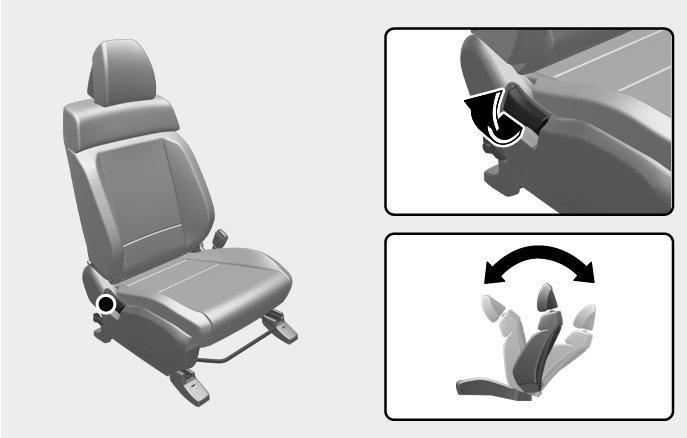

PDF 72쪽 이미지 2 | 크기: (687, 438)


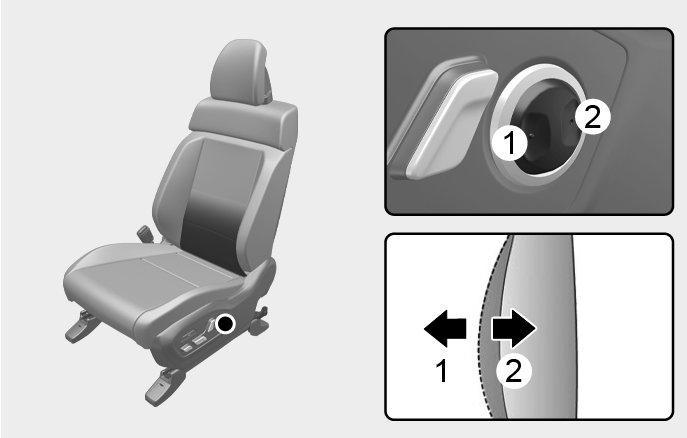

PDF 74쪽 이미지 1 | 크기: (687, 438)


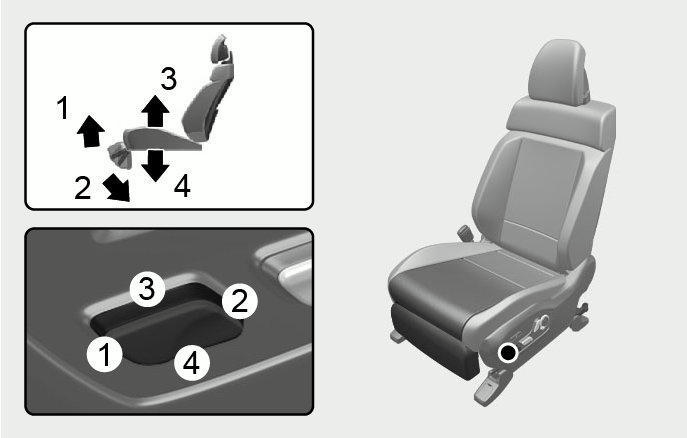

In [39]:
from IPython.display import display

# 가장 자주 나온 크기의 이미지 3개를 찾아 화면에 표시합니다.
표본_이미지 = []

for 페이지_번호, _ in 이미지_페이지_목록:
    페이지_이미지들 = reader.pages[페이지_번호 - 1].images

    for 이미지_번호, 이미지 in enumerate(페이지_이미지들, start=1):
        if 이미지.image.size == (687, 438):
            표본_이미지.append((페이지_번호, 이미지_번호, 이미지))
            if len(표본_이미지) == 3:
                break

    if len(표본_이미지) == 3:
        break

# 각 이미지의 PDF 쪽수와 번호를 표시하고 화면에 보여줍니다.
for 페이지_번호, 이미지_번호, 이미지 in 표본_이미지:
    print(
        f"PDF {페이지_번호}쪽 이미지 {이미지_번호}"
        f" | 크기: {이미지.image.size}"
    )
    display(이미지.image)

In [40]:
# 이미지와 설명을 연결할 세 페이지의 글을 확인합니다.
for 페이지_번호 in (70, 72, 74):
    원문 = reader.pages[페이지_번호 - 1].extract_text() or ""

    print(f"\n--- PDF {페이지_번호}쪽 원문 ---")
    print(원문[:1200])


--- PDF 70쪽 원문 ---
 ઱੄ 
프라임 나파 가죽(사양 적용 시)은 가죽 고유의 질감을 최대한 살린 특성으로 인해 다음의 현상
이 발생할 수 있습니다.
표면에 모공, 상처, 혈관 자국 등이 남아 있음
사용 시 눌린 자국, 주름이 생김
햇빛이나 열에 지속해서 노출되면 색상이 변형됨
가죽이 물기에 젖었다면 마른 천으로 물기를 제거하고 그늘에 건조하십시오.
가죽 표면에 스크래치가 날 수 있으니 날카로운 물체와 마찰하지 않도록 주의하십시오.
밝은 색상의 가죽은 오염이나 이염에 주의하십시오.
앞좌석
수동식(동승석)
전후 위치 조절하기
2C_AdjustSeatForwardBackwardmanual
좌석 쿠션의 앞쪽 레버를 당긴 채 좌석을 원하는 앞·뒤 위치로 조절하십시오.
조절 레버를 놓으면 고정됩니다.
좌석을 가볍게 흔들어 확실하게 고정됐는지 확인하십시오.
등받이 각도 조절하기
2C_AdjustSeatBackmanual
시트 및 안전 장치
65
•
-
-
-
•
•
•
1
2
3

--- PDF 72쪽 원문 ---
2C_AdjustSeatBackAuto
등받이 각도 조절 스위치 윗부분을 앞으로 당기면 등받이가 앞으로 숙여지고, 뒤로 밀면 등받이가
뒤로 젖혀집니다.
쿠션 각도/높낮이 조절하기
2C_AdjustSeatHeightAuto
쿠션 각도 조절(1)
조절 스위치의 앞쪽을 올리거나 내리면 쿠션의 앞부분이 올라가거나 내려옵니다.
좌석 높낮이 조절(2)
조절 스위치의 뒤쪽을 올리거나 내리면 좌석 전체가 올라가거나 내려옵니다.
허리 지지대(럼버 서포트) 조절하기
허리 지지대 전후 조절하기(A타입)
허리 받침대 조절 스위치의 앞부분(1)을 누르면 운전석 등받이 허리 지지 부분이 앞으로 튀어나
오고, 스위치의 뒷부분(2)을 누르면 허리 지지 부분이 뒤로 들어갑니다.
2C_AdjustSeatBackCushionAuto_1
허리 지지대 전후/상하 조절하기(운전석)(사양 적용 시)(B타입)
허리 지지대 조절 스위치의 앞부분(1)을 누르면 운전석 등받이 허리 지지 부분이

In [41]:
# PDF 72쪽 글의 앞부분만 확인합니다.
pdf72_text = reader.pages[71].extract_text() or ""

print("PDF 72쪽 글자 수:", len(pdf72_text))
print(pdf72_text[:900])

PDF 72쪽 글자 수: 608
2C_AdjustSeatBackAuto
등받이 각도 조절 스위치 윗부분을 앞으로 당기면 등받이가 앞으로 숙여지고, 뒤로 밀면 등받이가
뒤로 젖혀집니다.
쿠션 각도/높낮이 조절하기
2C_AdjustSeatHeightAuto
쿠션 각도 조절(1)
조절 스위치의 앞쪽을 올리거나 내리면 쿠션의 앞부분이 올라가거나 내려옵니다.
좌석 높낮이 조절(2)
조절 스위치의 뒤쪽을 올리거나 내리면 좌석 전체가 올라가거나 내려옵니다.
허리 지지대(럼버 서포트) 조절하기
허리 지지대 전후 조절하기(A타입)
허리 받침대 조절 스위치의 앞부분(1)을 누르면 운전석 등받이 허리 지지 부분이 앞으로 튀어나
오고, 스위치의 뒷부분(2)을 누르면 허리 지지 부분이 뒤로 들어갑니다.
2C_AdjustSeatBackCushionAuto_1
허리 지지대 전후/상하 조절하기(운전석)(사양 적용 시)(B타입)
허리 지지대 조절 스위치의 앞부분(1)을 누르면 운전석 등받이 허리 지지 부분이 앞으로 튀
어나오고, 스위치의 뒷부분(2)을 누르면 허리 지지 부분이 뒤로 들어갑니다.
허리 지지 부분의 상하 위치를 변경하려면 스위치의 윗부분(3)이나 아랫부분(4)을 누르십시
오.
시트 및 안전 장치
67
•
•
•
•
-
-


In [42]:
# PDF 74쪽 글의 앞부분만 확인합니다.
pdf74_text = reader.pages[73].extract_text() or ""

print("PDF 74쪽 글자 수:", len(pdf74_text))
print(pdf74_text[:900])

PDF 74쪽 글자 수: 385
2C_LegSupportCautionAdjust
҃Ҋ 
다리 받침대를 올리거나 내릴 때 앞좌석 시트 밑이나 근처 구조물에 발이나 손이 끼지 않도록
주의하십시오. 예기치 못한 상해가 발생할 수 있습니다.
어린이가 스위치를 조작하지 못하도록 주의하십시오. 어린이가 스위치를 조작하면 예기치 못한
상해가 발생할 수 있습니다.
 ઱੄ 
다리 받침대 끝에 앉거나 무거운 물건을 올려 놓지 마십시오. 다리 받침대 구동 장치가 손상될 수
있습니다.
ӝ 
다리 받침대를 사용하기 전에, 좌석을 뒤로 이동하십시오. 좌석이 주변 부품과 가까우면 다리 받침
대 사용이 제한됩니다.
릴렉션 기능 (릴렉션 컴포트 시트)
2C_RelaxationComfortSeatOperation
시트 및 안전 장치
69
•
•


In [43]:
from pathlib import Path

# PDF 74쪽에서 원문과 이미지 정보를 다시 가져옵니다.
pdf74_page = reader.pages[73]
pdf74_raw_text = pdf74_page.extract_text() or ""

# 검색용 글에서는 알아보기 어려운 이미지 내부 이름만 제거합니다.
pdf74_content = pdf74_raw_text
for 이미지_이름 in (
    "2C_LegSupportCautionAdjust",
    "2C_RelaxationComfortSeatOperation",
):
    pdf74_content = pdf74_content.replace(이미지_이름, "")

# 깨진 안전 표시를 의미에 맞는 한국어로 바꿉니다.
pdf74_content = (
    pdf74_content
    .replace("҃Ҋ", "[경고]")
    .replace("઱੄", "[주의]")
    .replace("ӝ", "[참고]")
    .strip()
)

# 그림에서 확인한 정보를 검색용 글에 덧붙입니다.
pdf74_content += (
    "\n\n[그림 설명] 좌석의 조절부와 번호별 움직임 방향이 표시되어 "
    "릴렉션 컴포트 시트 조작 방법을 안내한다."
)

# 이미지 파일은 만들지 않고, 페이지 안 이미지의 이름과 크기만 기록합니다.
pdf74_candidate_chunk = {
    "content": pdf74_content,
    "raw_text": pdf74_raw_text,
    "metadata": {
        "pdf_page_number": 74,
        "manual_page_number": 69,
        "content_type": "figure_with_text",
    },
    "image_parts": [
        {
            "name": 이미지.name,
            "size": 이미지.image.size,
        }
        for 이미지 in pdf74_page.images
    ],
}

print("출처:", pdf74_candidate_chunk["metadata"])
print("검색용 글자:\n", pdf74_candidate_chunk["content"])
print("이미지 정보:", pdf74_candidate_chunk["image_parts"])

출처: {'pdf_page_number': 74, 'manual_page_number': 69, 'content_type': 'figure_with_text'}
검색용 글자:
 [경고] 
다리 받침대를 올리거나 내릴 때 앞좌석 시트 밑이나 근처 구조물에 발이나 손이 끼지 않도록
주의하십시오. 예기치 못한 상해가 발생할 수 있습니다.
어린이가 스위치를 조작하지 못하도록 주의하십시오. 어린이가 스위치를 조작하면 예기치 못한
상해가 발생할 수 있습니다.
 [주의] 
다리 받침대 끝에 앉거나 무거운 물건을 올려 놓지 마십시오. 다리 받침대 구동 장치가 손상될 수
있습니다.
[참고] 
다리 받침대를 사용하기 전에, 좌석을 뒤로 이동하십시오. 좌석이 주변 부품과 가까우면 다리 받침
대 사용이 제한됩니다.
릴렉션 기능 (릴렉션 컴포트 시트)

시트 및 안전 장치
69
•
•

[그림 설명] 좌석의 조절부와 번호별 움직임 방향이 표시되어 릴렉션 컴포트 시트 조작 방법을 안내한다.
이미지 정보: [{'name': 'I2.jpg', 'size': (687, 438)}, {'name': 'I7.jpg', 'size': (686, 438)}]


이미지 이름: I2.jpg
이미지 크기: (687, 438)


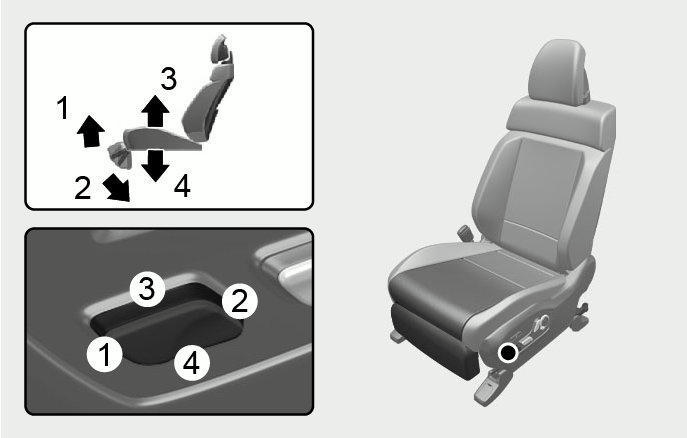

이미지 이름: I7.jpg
이미지 크기: (686, 438)


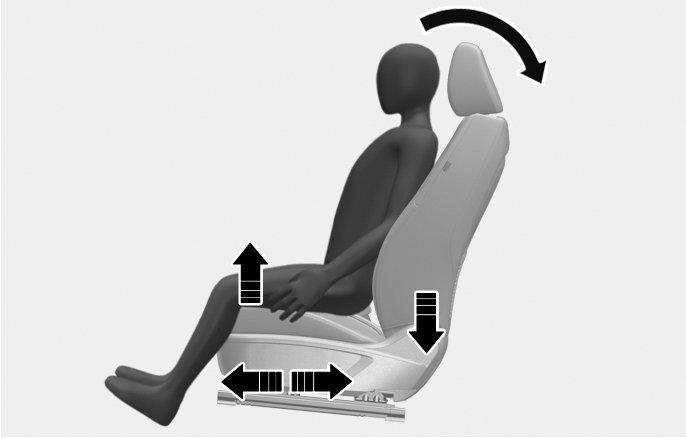

In [44]:
from IPython.display import display

# PDF 74쪽의 모든 그림을 이름과 함께 화면에 표시합니다.
for 이미지 in pdf74_page.images:
    print("이미지 이름:", 이미지.name)
    print("이미지 크기:", 이미지.image.size)
    display(이미지.image)

In [45]:
# PDF 74쪽 원문을 바탕으로 검색용 글을 다시 만듭니다.
pdf74_content = pdf74_candidate_chunk["raw_text"]

# 검색에 필요 없는 PDF 내부 이미지 이름만 제거합니다.
for 이미지_이름 in (
    "2C_LegSupportCautionAdjust",
    "2C_RelaxationComfortSeatOperation",
):
    pdf74_content = pdf74_content.replace(이미지_이름, "")

# 깨진 안전 표시를 사람이 읽을 수 있게 바꿉니다.
pdf74_content = (
    pdf74_content
    .replace("҃Ҋ", "[경고]")
    .replace("઱੄", "[주의]")
    .replace("ӝ", "[참고]")
    .strip()
)

# 그림마다 확인한 내용을 따로 설명합니다.
이미지별_설명 = {
    "I2.jpg": "번호 1~4가 표시된 좌석 조절 스위치와 좌석 움직임 방향을 보여준다.",
    "I7.jpg": "좌석의 앞뒤 위치, 높이, 등받이 기울기 조절 방향을 보여준다.",
}

설명_목록 = []

for 이미지_정보 in pdf74_candidate_chunk["image_parts"]:
    설명 = 이미지별_설명[이미지_정보["name"]]
    이미지_정보["description"] = 설명
    설명_목록.append(f"{이미지_정보['name']}: {설명}")

# 검색용 글에 두 그림의 설명을 각각 덧붙입니다.
pdf74_candidate_chunk["content"] = (
    pdf74_content
    + "\n\n[그림 설명]\n"
    + "\n".join(설명_목록)
)

print("이미지별 설명:", pdf74_candidate_chunk["image_parts"])
print("검색용 글 끝부분:", pdf74_candidate_chunk["content"][-300:])

이미지별 설명: [{'name': 'I2.jpg', 'size': (687, 438), 'description': '번호 1~4가 표시된 좌석 조절 스위치와 좌석 움직임 방향을 보여준다.'}, {'name': 'I7.jpg', 'size': (686, 438), 'description': '좌석의 앞뒤 위치, 높이, 등받이 기울기 조절 방향을 보여준다.'}]
검색용 글 끝부분: 치 못한
상해가 발생할 수 있습니다.
 [주의] 
다리 받침대 끝에 앉거나 무거운 물건을 올려 놓지 마십시오. 다리 받침대 구동 장치가 손상될 수
있습니다.
[참고] 
다리 받침대를 사용하기 전에, 좌석을 뒤로 이동하십시오. 좌석이 주변 부품과 가까우면 다리 받침
대 사용이 제한됩니다.
릴렉션 기능 (릴렉션 컴포트 시트)

시트 및 안전 장치
69
•
•

[그림 설명]
I2.jpg: 번호 1~4가 표시된 좌석 조절 스위치와 좌석 움직임 방향을 보여준다.
I7.jpg: 좌석의 앞뒤 위치, 높이, 등받이 기울기 조절 방향을 보여준다.


In [46]:
# 검색에 필요 없는 단독 페이지 번호와 장식 기호를 정리합니다.
제외할_줄 = {"69", "•", "-", "–"}
정리된_줄 = []

for 줄 in pdf74_candidate_chunk["content"].splitlines():
    if 줄.strip() in 제외할_줄:
        continue
    정리된_줄.append(줄.rstrip())

# 정리된 검색용 글을 임시 기록에 반영합니다.
pdf74_candidate_chunk["content"] = "\n".join(정리된_줄).strip()

print("검색용 글 끝부분:")
print(pdf74_candidate_chunk["content"][-300:])
print("\n원문(raw_text)은 그대로 보관:", bool(pdf74_candidate_chunk["raw_text"]))

검색용 글 끝부분:
를 조작하면 예기치 못한
상해가 발생할 수 있습니다.
 [주의]
다리 받침대 끝에 앉거나 무거운 물건을 올려 놓지 마십시오. 다리 받침대 구동 장치가 손상될 수
있습니다.
[참고]
다리 받침대를 사용하기 전에, 좌석을 뒤로 이동하십시오. 좌석이 주변 부품과 가까우면 다리 받침
대 사용이 제한됩니다.
릴렉션 기능 (릴렉션 컴포트 시트)

시트 및 안전 장치

[그림 설명]
I2.jpg: 번호 1~4가 표시된 좌석 조절 스위치와 좌석 움직임 방향을 보여준다.
I7.jpg: 좌석의 앞뒤 위치, 높이, 등받이 기울기 조절 방향을 보여준다.

원문(raw_text)은 그대로 보관: True


In [47]:
from statistics import mean, median

# 색인과 짧은 PDF 764쪽 표시는 빼고 본문 페이지의 글자 수만 모읍니다.
본문_페이지_글자수 = [
    (페이지_번호, 글자수)
    for 페이지_번호, 글자수 in 페이지별_글자수
    if 페이지_번호 <= 763
]

# 본문에서 길이가 가장 긴 페이지를 찾습니다.
본문_긴_페이지 = sorted(
    본문_페이지_글자수,
    key=lambda 항목: 항목[1],
    reverse=True,
)

print("글자가 있는 본문 페이지 수:", len(본문_페이지_글자수))
print("본문 평균 글자 수:", round(mean(글자수 for _, 글자수 in 본문_페이지_글자수), 1))
print("본문 중앙 글자 수:", median(글자수 for _, 글자수 in 본문_페이지_글자수))
print("본문에서 가장 긴 페이지 10개:", 본문_긴_페이지[:10])

글자가 있는 본문 페이지 수: 761
본문 평균 글자 수: 694.0
본문 중앙 글자 수: 586
본문에서 가장 긴 페이지 10개: [(693, 4130), (183, 4099), (184, 4060), (185, 4059), (186, 4041), (379, 3969), (461, 3893), (462, 3821), (380, 3697), (694, 3566)]


In [48]:
# 긴 페이지의 제목·초반 내용과 이미지 개수를 함께 살펴봅니다.
for 페이지_번호, 글자수 in 본문_긴_페이지[:10]:
    페이지 = reader.pages[페이지_번호 - 1]
    원문 = 페이지.extract_text() or ""

    # 빈 줄을 빼고 앞의 몇 줄만 골라 주제 파악에 사용합니다.
    앞부분_줄 = [
        줄.strip()
        for 줄 in 원문.splitlines()
        if 줄.strip()
    ][:4]

    print(f"\nPDF {페이지_번호}쪽 | 글자 수: {글자수}")
    print("이미지 개수:", len(페이지.images))
    print("앞부분:", " / ".join(앞부분_줄))


PDF 693쪽 | 글자 수: 4130
이미지 개수: 0
앞부분: 엔진룸의  명칭..................................................................................................................690 / 점검 및 정비.....................................................................................................................691 / 필수 준수 사항.............................................................................................................691 / 점검 및 정비 시 주의 사항............................................................................................691

PDF 183쪽 | 글자 수: 4099
이미지 개수: 0
앞부분: 스마트 키......................................................................................................................... 183 / 스마트 키 사용 방법.....................................................................................................183 / 스마트 키 사용 시 주의 사항.........................................................................................187 / 건전지 교체 방법.............................................................

In [49]:
# 목차형으로 확인한 페이지는 분석 목록에서만 잠시 제외합니다.
목차형_페이지 = {
    183, 184, 185, 186,
    379, 380,
    461, 462,
    693, 694,
}

# 나머지 본문 페이지 중 글자 수가 많은 순서로 확인합니다.
나머지_긴_페이지 = sorted(
    [
        (페이지_번호, 글자수)
        for 페이지_번호, 글자수 in 본문_페이지_글자수
        if 페이지_번호 not in 목차형_페이지
    ],
    key=lambda 항목: 항목[1],
    reverse=True,
)

print("다음으로 긴 페이지 10개:", 나머지_긴_페이지[:10])

다음으로 긴 페이지 10개: [(49, 3555), (659, 3516), (63, 3350), (187, 3263), (7, 2496), (33, 2489), (34, 2438), (35, 2357), (29, 2019), (31, 1781)]


In [50]:
# 남은 긴 페이지의 주제와 이미지 개수를 확인합니다.
for 페이지_번호, 글자수 in 나머지_긴_페이지[:10]:
    페이지 = reader.pages[페이지_번호 - 1]
    원문 = 페이지.extract_text() or ""
    한줄_원문 = 원문.replace("\n", " ")

    print(f"\nPDF {페이지_번호}쪽 | 글자 수: {글자수}")
    print("이미지 개수:", len(페이지.images))
    print("앞부분:", 한줄_원문[:180])
    print("끝부분:", 한줄_원문[-100:])


PDF 49쪽 | 글자 수: 3555
이미지 개수: 0
앞부분: 1일 1회 일상 점검...............................................................................................................46 엔진룸 점검.................................................
끝부분: ..................................................................................56 2. 안전 및 주의 사항 2

PDF 659쪽 | 글자 수: 3516
이미지 개수: 0
앞부분: 주행 중 경고.................................................................................................................... 655 비상 경고등..............................................
끝부분: ..................................................................................687 8. 비상시 응급 조치 8

PDF 63쪽 | 글자 수: 3350
이미지 개수: 0
앞부분: 좌석...................................................................................................................................59 앞좌석.........................................
끝부분: ................................................................................ 141 3. 시트 및 안전 장치 3

PDF 187쪽 | 글자 수: 3263
이미지 

PDF 33쪽 글 앞부분:
차량 내부 I
1C_SideInsideVehicleOverview
본 도안은 적용된 사양에 따라 실제 차량과 다를 수 있습니다.
도어 핸들(실내).......................................................................................................................................................... 213
운전석 자세 메모리 시스템..........................................................................................................................................224
에르고 모션 시트 버튼...................................................................................................................................................65
실외 미러 접이 버튼...................................................................................................................................

PDF 33쪽 이미지 개수: 1
이미지 이름: I1.jpg | 크기: (1454, 1158)


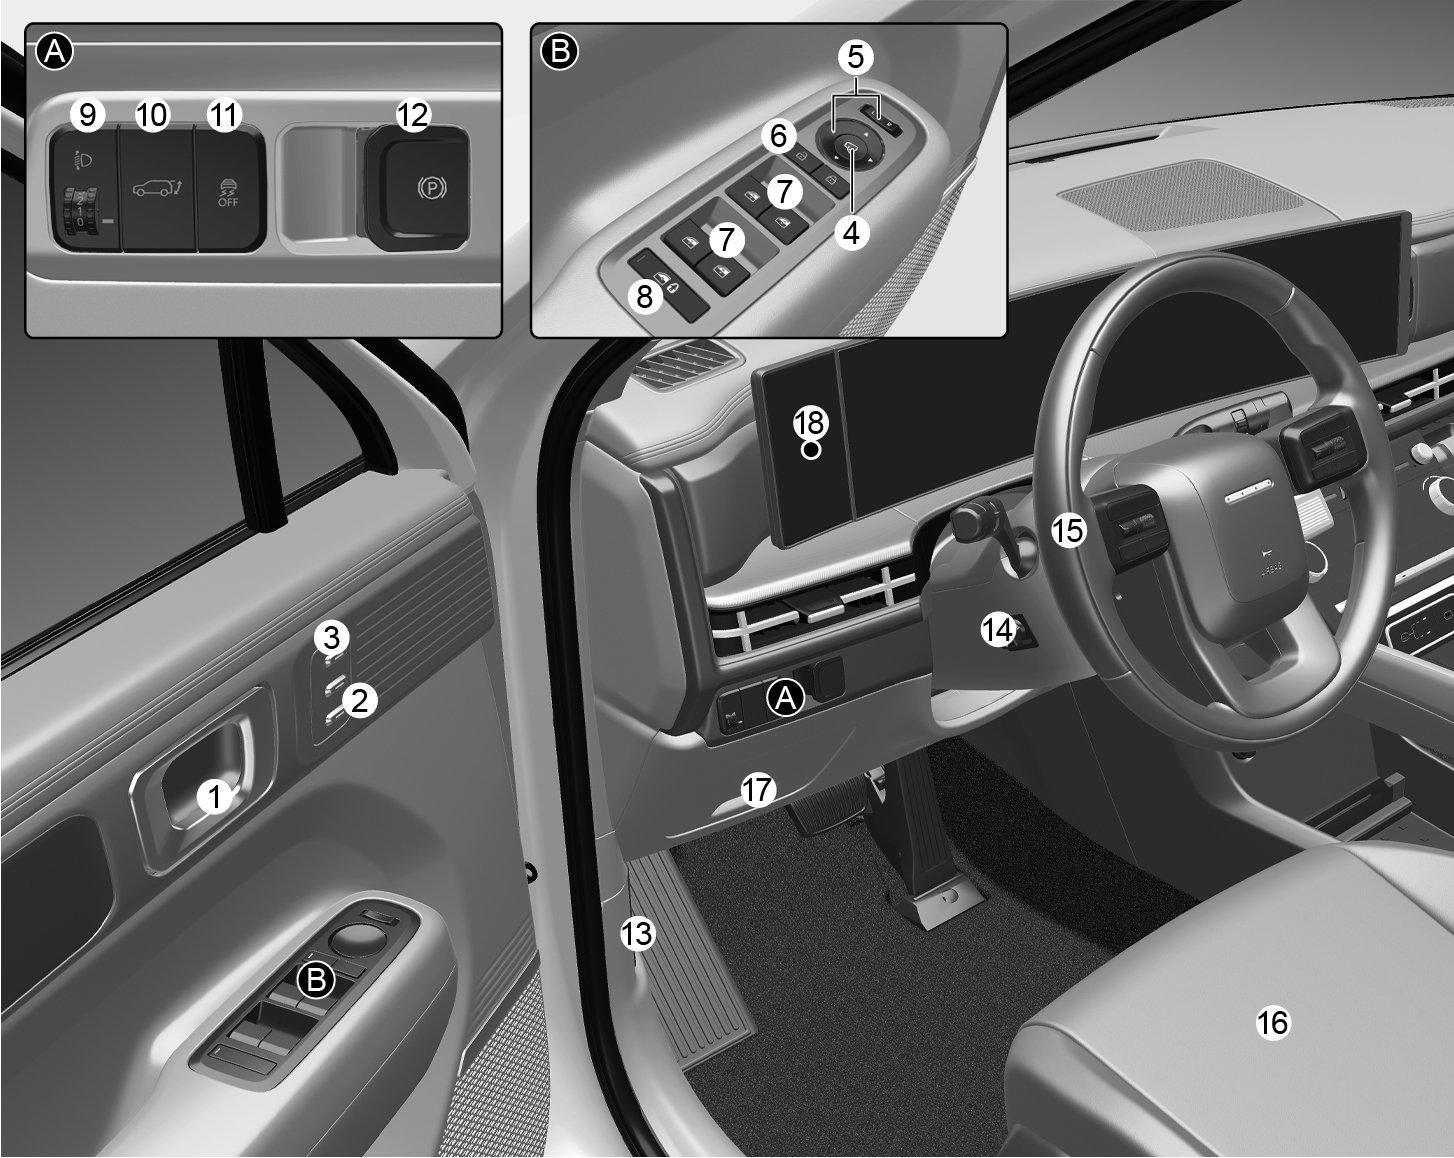

In [51]:
from IPython.display import display

# PDF 33쪽의 글과 이미지가 몇 개인지 확인합니다.
pdf33_page = reader.pages[32]
pdf33_text = pdf33_page.extract_text() or ""

print("PDF 33쪽 글 앞부분:")
print(pdf33_text[:700])

print("\nPDF 33쪽 이미지 개수:", len(pdf33_page.images))

# 해당 페이지의 이미지를 파일로 저장하지 않고 화면에 표시합니다.
for 이미지 in pdf33_page.images:
    print("이미지 이름:", 이미지.name, "| 크기:", 이미지.image.size)
    display(이미지.image)

In [52]:
from pathlib import Path
from pypdf import PdfReader

# PDF 파일을 열고, PDF 33쪽과 34쪽을 가져옵니다.
# 파이썬 목록은 0부터 세므로 PDF 33쪽은 [32], 34쪽은 [33]입니다.
pdf_path = Path("../data/santafe_hev_manual.pdf")
reader = PdfReader(str(pdf_path))

page33 = reader.pages[32]
page34 = reader.pages[33]

# 원본에서 추출한 글을 보관합니다.
pdf33_raw = page33.extract_text(extraction_mode="layout")
pdf34_raw = page34.extract_text(extraction_mode="layout")

# PDF 34쪽의 앞부분은 PDF 33쪽 그림의 번호 16~18 설명입니다.
# "차량 내부 II" 제목부터는 다음 그림이므로 그 앞까지만 가져옵니다.
continuation_raw = pdf34_raw.split("차량 내부 II", 1)[0].strip()
raw_text = pdf33_raw + "\n\n[PDF 34쪽에서 이어지는 항목]\n" + continuation_raw

# 이미지에 표시된 번호와 부품 이름, 매뉴얼 설명 페이지를 연결합니다.
numbered_items = [
    "1: 도어 핸들(실내) — 매뉴얼 213쪽",
    "2: 운전석 자세 메모리 시스템 — 매뉴얼 224쪽",
    "3: 에르고 모션 시트 버튼 — 매뉴얼 65쪽",
    "4: 실외 미러 접이 버튼 — 매뉴얼 242쪽",
    "5: 실외 미러 조절 스위치 — 매뉴얼 242쪽",
    "6: 중앙 도어 잠금/잠금 해제 버튼 — 매뉴얼 214쪽",
    "7: 유리창 열림/닫힘 스위치 — 매뉴얼 249쪽",
    "8: 유리창 열림/닫힘 잠금 버튼, 전자식 차일드 락 버튼 — 매뉴얼 249쪽, 216쪽",
    "9: 전조등 각도 조절 장치 — 매뉴얼 300쪽",
    "10: 테일게이트 열림 버튼 — 매뉴얼 263쪽, 270쪽",
    "11: 차체 자세 제어(ESC) OFF 버튼 — 매뉴얼 419쪽",
    "12: 전자식 파킹 브레이크(EPB) 스위치 — 매뉴얼 410쪽",
    "13: 후드 열림 레버 — 매뉴얼 261쪽",
    "14: 스티어링 휠 위치 조절 — 매뉴얼 228쪽",
    "15: 스티어링 휠 — 매뉴얼 228쪽",
    "16: 시트 — 매뉴얼 59쪽",
    "17: 실내 퓨즈 — 매뉴얼 733쪽",
    "18: 지문 인증 시스템 — 매뉴얼 206쪽",
]

# 검색에 사용할 글과 출처·이미지 정보를 하나의 기록으로 묶습니다.
image = page33.images[0]

vehicle_inside_i_record = {
    "content": (
        "차량 내부 I. 적용 사양에 따라 실제 차량과 다를 수 있습니다.\n"
        + "\n".join(numbered_items)
        + "\n그림은 차량 내부 부품의 위치를 번호로 표시한 안내도이다."
    ),
    "raw_text": raw_text,
    "metadata": {
        "pdf_page_number": 33,
        "continued_on_pdf_page": 34,
        "manual_page_number": 28,
        "content_type": "vehicle_overview_navigation",
    },
    "image_parts": [
        {
            "name": image.name,
            "size": image.image.size,
            "description": (
                "차량 내부의 주요 부품 위치를 1~18번으로 표시한 안내도. "
                "A와 B 영역은 조작부를 확대해 보여준다."
            ),
        }
    ],
}

# 저장하지 않고, 만들어진 기록의 핵심 정보만 확인합니다.
print("기록 종류:", vehicle_inside_i_record["metadata"]["content_type"])
print("원본 글자 수:", len(vehicle_inside_i_record["raw_text"]))
print("이미지 정보:", vehicle_inside_i_record["image_parts"])
print("\n검색용 글:")
print(vehicle_inside_i_record["content"])

기록 종류: vehicle_overview_navigation
원본 글자 수: 3712
이미지 정보: [{'name': 'I1.jpg', 'size': (1454, 1158), 'description': '차량 내부의 주요 부품 위치를 1~18번으로 표시한 안내도. A와 B 영역은 조작부를 확대해 보여준다.'}]

검색용 글:
차량 내부 I. 적용 사양에 따라 실제 차량과 다를 수 있습니다.
1: 도어 핸들(실내) — 매뉴얼 213쪽
2: 운전석 자세 메모리 시스템 — 매뉴얼 224쪽
3: 에르고 모션 시트 버튼 — 매뉴얼 65쪽
4: 실외 미러 접이 버튼 — 매뉴얼 242쪽
5: 실외 미러 조절 스위치 — 매뉴얼 242쪽
6: 중앙 도어 잠금/잠금 해제 버튼 — 매뉴얼 214쪽
7: 유리창 열림/닫힘 스위치 — 매뉴얼 249쪽
8: 유리창 열림/닫힘 잠금 버튼, 전자식 차일드 락 버튼 — 매뉴얼 249쪽, 216쪽
9: 전조등 각도 조절 장치 — 매뉴얼 300쪽
10: 테일게이트 열림 버튼 — 매뉴얼 263쪽, 270쪽
11: 차체 자세 제어(ESC) OFF 버튼 — 매뉴얼 419쪽
12: 전자식 파킹 브레이크(EPB) 스위치 — 매뉴얼 410쪽
13: 후드 열림 레버 — 매뉴얼 261쪽
14: 스티어링 휠 위치 조절 — 매뉴얼 228쪽
15: 스티어링 휠 — 매뉴얼 228쪽
16: 시트 — 매뉴얼 59쪽
17: 실내 퓨즈 — 매뉴얼 733쪽
18: 지문 인증 시스템 — 매뉴얼 206쪽
그림은 차량 내부 부품의 위치를 번호로 표시한 안내도이다.


In [53]:
# 안내도의 본 페이지와 이어지는 목록의 매뉴얼 쪽수를 각각 기록합니다.
vehicle_inside_i_record["metadata"]["continuation_manual_page_number"] = 29

print("출처 정보:", vehicle_inside_i_record["metadata"])

출처 정보: {'pdf_page_number': 33, 'continued_on_pdf_page': 34, 'manual_page_number': 28, 'content_type': 'vehicle_overview_navigation', 'continuation_manual_page_number': 29}


In [54]:
# 검색용 목록의 각 부품 이름이 원본 글에도 있는지 확인합니다.
missing_items = []

for item in numbered_items:
    # "번호: 부품 이름 — 매뉴얼 페이지"에서 부품 이름만 꺼냅니다.
    item_details = item.split(": ", 1)[1]
    item_name = item_details.split(" — 매뉴얼 ", 1)[0]

    if item_name not in vehicle_inside_i_record["raw_text"]:
        missing_items.append(item_name)

print("검색용 목록 항목 수:", len(numbered_items))
print("원본에서 찾지 못한 부품 이름:", missing_items)
print(
    "다음 그림 제목이 원본에 섞였나요?:",
    "차량 내부 II" in vehicle_inside_i_record["raw_text"],
)

검색용 목록 항목 수: 18
원본에서 찾지 못한 부품 이름: []
다음 그림 제목이 원본에 섞였나요?: False


In [55]:
import re
from pathlib import Path
from pypdf import PdfReader

# PDF 34쪽과 35쪽의 글을 다시 읽습니다.
pdf_path = Path("../data/santafe_hev_manual.pdf")
reader = PdfReader(str(pdf_path))

pdf34_text = reader.pages[33].extract_text(extraction_mode="layout")
pdf35_text = reader.pages[34].extract_text(extraction_mode="layout")

# PDF 34쪽에서는 "차량 내부 II"부터 다음 그림 제목 전까지가 대상입니다.
vehicle_ii_start = pdf34_text.split("차량 내부 II", 1)[1]

# PDF 35쪽에서는 "차량 내부 III" 앞까지가 차량 내부 II의 이어지는 목록입니다.
vehicle_ii_continuation = pdf35_text.split("차량 내부 III", 1)[0]

# 각 구간에서 번호로 시작하는 부품 항목을 찾습니다.
page34_numbers = re.findall(r"(?m)^\s*(\d+):", vehicle_ii_start)
page35_numbers = re.findall(r"(?m)^\s*(\d+):", vehicle_ii_continuation)

print("PDF 34쪽의 차량 내부 II 번호:", page34_numbers)
print("PDF 35쪽에서 이어지는 번호:", page35_numbers)
print("PDF 34쪽 이미지 개수:", len(reader.pages[33].images))

PDF 34쪽의 차량 내부 II 번호: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11']
PDF 35쪽에서 이어지는 번호: ['12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24']
PDF 34쪽 이미지 개수: 1


In [56]:
from pathlib import Path
from pypdf import PdfReader

# PDF 34쪽과 35쪽을 다시 읽습니다.
pdf_path = Path("../data/santafe_hev_manual.pdf")
reader = PdfReader(str(pdf_path))

page34 = reader.pages[33]
page35 = reader.pages[34]

pdf34_raw = page34.extract_text(extraction_mode="layout")
pdf35_raw = page35.extract_text(extraction_mode="layout")

# PDF 34쪽에서 차량 내부 II 제목 이후만 가져옵니다.
# 앞에 있는 차량 내부 I의 이어지는 항목은 제외됩니다.
vehicle_ii_raw = "차량 내부 II" + pdf34_raw.split("차량 내부 II", 1)[1]

# PDF 35쪽에서 차량 내부 III 제목 전까지만 가져옵니다.
# 이 부분에는 차량 내부 II의 12~24번이 있습니다.
vehicle_ii_continuation_raw = pdf35_raw.split("차량 내부 III", 1)[0].strip()

# 번호, 부품 이름, 매뉴얼 설명 페이지를 검색용 목록으로 정리합니다.
numbered_items = [
    "1: 클러스터 — 매뉴얼 143쪽",
    "2: 경음기 — 매뉴얼 232쪽",
    "3: 운전석 에어백 — 매뉴얼 122쪽",
    "4: 시동 버튼 — 매뉴얼 377쪽",
    "5: 자동 변속기(전자식 변속 칼럼) — 매뉴얼 383쪽",
    "6: 인포테인먼트 시스템 — 매뉴얼 367쪽",
    "7: 비상 경고등 — 매뉴얼 655쪽",
    "8: 히터 및 에어컨 — 매뉴얼 318쪽",
    "9: 자동 정차 기능(Auto Hold) 버튼 — 매뉴얼 415쪽",
    "10: 험로 주행 모드 / 통합 주행 모드 시스템 — 매뉴얼 431쪽, 439쪽, 442쪽",
    "11: 경사로 저속 주행(DBC) 버튼 — 매뉴얼 427쪽",
    "12: 주차/뷰 버튼 — 매뉴얼 593쪽",
    "13: 주차 안전 버튼 — 매뉴얼 623쪽, 631쪽",
    "14: USB 충전 단자/USB 단자 — 매뉴얼 353쪽, 369쪽",
    "15: USB 충전 단자/USB 단자 기능 전환 버튼 — 매뉴얼 369쪽",
    "16: USB 충전 단자 — 매뉴얼 358쪽",
    "17: UV-C 살균 소독 시스템 작동 버튼 — 매뉴얼 349쪽",
    "18: 스마트폰 무선 충전 표시등/시스템 — 매뉴얼 355쪽",
    "19: 글로브 박스 — 매뉴얼 343쪽",
    "20: 동승석 에어백 — 매뉴얼 123쪽",
    "21: 동승석 멀티 트레이 — 매뉴얼 343쪽",
    "22: 동승석 오픈 트레이 — 매뉴얼 344쪽",
    "23: 양방향 멀티 콘솔 — 매뉴얼 342쪽",
    "24: 슬라이딩 트레이 — 매뉴얼 345쪽",
]

# 이미지 파일을 저장하지 않고, 이름과 크기만 확인합니다.
image = page34.images[0]

vehicle_inside_ii_record = {
    "content": (
        "차량 내부 II. 적용 사양에 따라 실제 차량과 다를 수 있습니다.\n"
        + "\n".join(numbered_items)
        + "\n그림은 차량 내부 주요 부품의 위치를 번호로 표시한 안내도이다."
    ),
    "raw_text": (
        vehicle_ii_raw
        + "\n\n[PDF 35쪽에서 이어지는 항목]\n"
        + vehicle_ii_continuation_raw
    ),
    "metadata": {
        "pdf_page_number": 34,
        "continued_on_pdf_page": 35,
        "manual_page_number": 29,
        "continuation_manual_page_number": 30,
        "content_type": "vehicle_overview_navigation",
    },
    "image_parts": [
        {
            "name": image.name,
            "size": image.image.size,
            "description": "차량 내부 II의 주요 부품 위치를 번호로 표시한 안내도.",
        }
    ],
}

# 저장하지 않고 후보 기록의 요약을 확인합니다.
print("기록 종류:", vehicle_inside_ii_record["metadata"]["content_type"])
print("검색용 항목 수:", len(numbered_items))
print("원본 글자 수:", len(vehicle_inside_ii_record["raw_text"]))
print("이미지 정보:", vehicle_inside_ii_record["image_parts"])
print("\n검색용 글:")
print(vehicle_inside_ii_record["content"])

기록 종류: vehicle_overview_navigation
검색용 항목 수: 24
원본 글자 수: 4256
이미지 정보: [{'name': 'I1.jpg', 'size': (1454, 1158), 'description': '차량 내부 II의 주요 부품 위치를 번호로 표시한 안내도.'}]

검색용 글:
차량 내부 II. 적용 사양에 따라 실제 차량과 다를 수 있습니다.
1: 클러스터 — 매뉴얼 143쪽
2: 경음기 — 매뉴얼 232쪽
3: 운전석 에어백 — 매뉴얼 122쪽
4: 시동 버튼 — 매뉴얼 377쪽
5: 자동 변속기(전자식 변속 칼럼) — 매뉴얼 383쪽
6: 인포테인먼트 시스템 — 매뉴얼 367쪽
7: 비상 경고등 — 매뉴얼 655쪽
8: 히터 및 에어컨 — 매뉴얼 318쪽
9: 자동 정차 기능(Auto Hold) 버튼 — 매뉴얼 415쪽
10: 험로 주행 모드 / 통합 주행 모드 시스템 — 매뉴얼 431쪽, 439쪽, 442쪽
11: 경사로 저속 주행(DBC) 버튼 — 매뉴얼 427쪽
12: 주차/뷰 버튼 — 매뉴얼 593쪽
13: 주차 안전 버튼 — 매뉴얼 623쪽, 631쪽
14: USB 충전 단자/USB 단자 — 매뉴얼 353쪽, 369쪽
15: USB 충전 단자/USB 단자 기능 전환 버튼 — 매뉴얼 369쪽
16: USB 충전 단자 — 매뉴얼 358쪽
17: UV-C 살균 소독 시스템 작동 버튼 — 매뉴얼 349쪽
18: 스마트폰 무선 충전 표시등/시스템 — 매뉴얼 355쪽
19: 글로브 박스 — 매뉴얼 343쪽
20: 동승석 에어백 — 매뉴얼 123쪽
21: 동승석 멀티 트레이 — 매뉴얼 343쪽
22: 동승석 오픈 트레이 — 매뉴얼 344쪽
23: 양방향 멀티 콘솔 — 매뉴얼 342쪽
24: 슬라이딩 트레이 — 매뉴얼 345쪽
그림은 차량 내부 주요 부품의 위치를 번호로 표시한 안내도이다.


In [57]:
# 항목 5와 18의 이름을 원문 표현에 맞춥니다.
numbered_items[4] = "5: 자동 변속기 (전자식 변속 칼럼) — 매뉴얼 383쪽"
numbered_items[17] = (
    "18: 스마트폰 무선 충전 표시등/스마트폰 무선 충전 시스템 — 매뉴얼 355쪽"
)

# 수정한 목록으로 검색용 글을 다시 만듭니다.
vehicle_inside_ii_record["content"] = (
    "차량 내부 II. 적용 사양에 따라 실제 차량과 다를 수 있습니다.\n"
    + "\n".join(numbered_items)
    + "\n그림은 차량 내부 주요 부품의 위치를 번호로 표시한 안내도이다."
)

# 각 부품 이름이 원본 글에도 포함되어 있는지 확인합니다.
missing_items = []

for item in numbered_items:
    item_details = item.split(": ", 1)[1]
    item_name = item_details.split(" — 매뉴얼 ", 1)[0]

    if item_name not in vehicle_inside_ii_record["raw_text"]:
        missing_items.append(item_name)

print("검색용 목록 항목 수:", len(numbered_items))
print("원본에서 찾지 못한 부품 이름:", missing_items)
print(
    "차량 내부 III가 섞였나요?:",
    "차량 내부 III" in vehicle_inside_ii_record["raw_text"],
)

검색용 목록 항목 수: 24
원본에서 찾지 못한 부품 이름: []
차량 내부 III가 섞였나요?: False


In [58]:
from pathlib import Path
from pypdf import PdfReader

# PDF 35쪽과 36쪽을 읽습니다.
pdf_path = Path("../data/santafe_hev_manual.pdf")
reader = PdfReader(str(pdf_path))

page35 = reader.pages[34]
page36 = reader.pages[35]

pdf35_raw = page35.extract_text(extraction_mode="layout")
pdf36_raw = page36.extract_text(extraction_mode="layout")

# PDF 35쪽에서 차량 내부 III 제목 이후만 가져옵니다.
# 그 앞에 있는 차량 내부 II의 12~24번 목록은 제외됩니다.
vehicle_iii_raw = "차량 내부 III" + pdf35_raw.split("차량 내부 III", 1)[1]

# PDF 36쪽에는 차량 내부 III의 2~10번 항목이 이어집니다.
vehicle_iii_continuation_raw = pdf36_raw.strip()

# 번호, 부품 이름, 매뉴얼 설명 페이지를 검색용 목록으로 정리합니다.
numbered_items = [
    "1: 주행 보조 버튼 — 매뉴얼 541쪽, 576쪽",
    "2: 클러스터 메뉴 설정 버튼 — 매뉴얼 170쪽",
    "3: 차간거리 버튼 — 매뉴얼 541쪽",
    "4: 차로 주행 보조 버튼 — 매뉴얼 492쪽, 570쪽",
    "5: 블루투스 핸즈프리 버튼 — 매뉴얼 370쪽",
    "6: 음성 인식 버튼 — 매뉴얼 372쪽",
    "7: 패들 쉬프트 — 매뉴얼 395쪽",
    "8: 조명 스위치 — 매뉴얼 296쪽",
    "9: 와이퍼/와셔 스위치 — 매뉴얼 313쪽",
    "10: 오디오 리모컨 스위치 — 매뉴얼 368쪽",
]

# 이미지는 저장하지 않고 이름과 크기만 기록합니다.
image = page35.images[0]

vehicle_inside_iii_record = {
    "content": (
        "차량 내부 III. 적용 사양에 따라 실제 차량과 다를 수 있습니다.\n"
        + "\n".join(numbered_items)
        + "\n그림은 차량 내부 주요 부품의 위치를 번호로 표시한 안내도이다."
    ),
    "raw_text": (
        vehicle_iii_raw
        + "\n\n[PDF 36쪽에서 이어지는 항목]\n"
        + vehicle_iii_continuation_raw
    ),
    "metadata": {
        "pdf_page_number": 35,
        "continued_on_pdf_page": 36,
        "manual_page_number": 30,
        "continuation_manual_page_number": 31,
        "content_type": "vehicle_overview_navigation",
    },
    "image_parts": [
        {
            "name": image.name,
            "size": image.image.size,
            "description": "차량 내부 III의 주요 부품 위치를 번호로 표시한 안내도.",
        }
    ],
}

# 파일에 저장하지 않고 후보 기록의 요약을 확인합니다.
print("기록 종류:", vehicle_inside_iii_record["metadata"]["content_type"])
print("검색용 항목 수:", len(numbered_items))
print("원본 글자 수:", len(vehicle_inside_iii_record["raw_text"]))
print("이미지 정보:", vehicle_inside_iii_record["image_parts"])
print("\n검색용 글:")
print(vehicle_inside_iii_record["content"])

기록 종류: vehicle_overview_navigation
검색용 항목 수: 10
원본 글자 수: 2210
이미지 정보: [{'name': 'I1.jpg', 'size': (1454, 1158), 'description': '차량 내부 III의 주요 부품 위치를 번호로 표시한 안내도.'}]

검색용 글:
차량 내부 III. 적용 사양에 따라 실제 차량과 다를 수 있습니다.
1: 주행 보조 버튼 — 매뉴얼 541쪽, 576쪽
2: 클러스터 메뉴 설정 버튼 — 매뉴얼 170쪽
3: 차간거리 버튼 — 매뉴얼 541쪽
4: 차로 주행 보조 버튼 — 매뉴얼 492쪽, 570쪽
5: 블루투스 핸즈프리 버튼 — 매뉴얼 370쪽
6: 음성 인식 버튼 — 매뉴얼 372쪽
7: 패들 쉬프트 — 매뉴얼 395쪽
8: 조명 스위치 — 매뉴얼 296쪽
9: 와이퍼/와셔 스위치 — 매뉴얼 313쪽
10: 오디오 리모컨 스위치 — 매뉴얼 368쪽
그림은 차량 내부 주요 부품의 위치를 번호로 표시한 안내도이다.


In [59]:
import re

# 기록 하나를 받아 항목 수, 원본에 없는 이름을 돌려주는 확인 함수입니다.
def check_record(record):
    # 검색용 글에서 "숫자:"로 시작하는 줄만 부품 목록으로 모읍니다.
    item_lines = [
        line
        for line in record["content"].splitlines()
        if re.match(r"^\d+:", line)
    ]

    missing_names = []

    # 각 부품 이름이 원본 글에도 있는지 확인합니다.
    for line in item_lines:
        item_details = line.split(": ", 1)[1]
        item_name = item_details.split(" — 매뉴얼 ", 1)[0]

        if item_name not in record["raw_text"]:
            missing_names.append(item_name)

    return len(item_lines), missing_names


# 만든 세 기록을 같은 방법으로 확인합니다.
records_to_check = [
    ("차량 내부 I", vehicle_inside_i_record, "차량 내부 II"),
    ("차량 내부 II", vehicle_inside_ii_record, "차량 내부 III"),
    ("차량 내부 III", vehicle_inside_iii_record, "차량 내부 IV"),
]

for title, record, next_title in records_to_check:
    item_count, missing_names = check_record(record)

    print(f"\n{title}")
    print("검색용 항목 수:", item_count)
    print("원본에서 찾지 못한 이름:", missing_names)
    print("다음 안내도 제목이 섞였나요?:", next_title in record["raw_text"])


차량 내부 I
검색용 항목 수: 18
원본에서 찾지 못한 이름: []
다음 안내도 제목이 섞였나요?: False

차량 내부 II
검색용 항목 수: 24
원본에서 찾지 못한 이름: []
다음 안내도 제목이 섞였나요?: False

차량 내부 III
검색용 항목 수: 10
원본에서 찾지 못한 이름: []
다음 안내도 제목이 섞였나요?: False


In [61]:
import re

# PDF 31쪽과 32쪽을 확인합니다.
for pdf_page_number in (31, 32):
    page = reader.pages[pdf_page_number - 1]
    page_text = page.extract_text(extraction_mode="layout")

    # 제목과 번호로 시작하는 항목 줄만 골라냅니다.
    headings = [
        line.strip()
        for line in page_text.splitlines()
        if "차량 외부" in line or "_Overview" in line
    ]
    numbered_lines = [
        line.strip()
        for line in page_text.splitlines()
        if re.match(r"^\s*\d+:", line)
    ]

    print(f"\nPDF {pdf_page_number}쪽")
    print("안내도 제목:", headings)
    print("번호 항목:", numbered_lines)
    print("이미지 개수:", len(page.images))


PDF 31쪽
안내도 제목: ['차량 외부 II']
번호 항목: ['1:   도어............................................................................................................................................................................ 211', '2:   연료 주입구.................................................................................................................................................................274', '3:   램프(뒤) ............................................................................................................................................................ 296, 741', '4:   테일게이트......................................................................................................................................................... 263, 270', '5:   보조 제동등.................................................................................................................................................................742', '6:   안테나....................................................

In [62]:
page31 = reader.pages[30]
pdf31_raw = page31.extract_text(extraction_mode="layout")

# 이미지 파일은 저장하지 않고, PDF에서 이름과 크기만 읽습니다.
image = page31.images[0]

numbered_items = [
    "1: 도어 — 매뉴얼 211쪽",
    "2: 연료 주입구 — 매뉴얼 274쪽",
    "3: 램프(뒤) — 매뉴얼 296쪽, 741쪽",
    "4: 테일게이트 — 매뉴얼 263쪽, 270쪽",
    "5: 보조 제동등 — 매뉴얼 742쪽",
    "6: 안테나 — 매뉴얼 367쪽",
    "7: 광각-후방 카메라 — 매뉴얼 596쪽",
    "8: 후퇴등 — 매뉴얼 741쪽",
    "9: 테일게이트 열림/닫힘 버튼(실외) — 매뉴얼 266쪽, 270쪽",
    "10: 히든 타입 어시스트 핸들 — 매뉴얼 365쪽",
]

# 차량 외부 II 안내도와 번호별 부품 목록을 하나의 후보 기록으로 만듭니다.
vehicle_exterior_ii_record = {
    "content": (
        "차량 외부 II. 이 그림은 실제 차량과 다를 수 있습니다.\n"
        + "\n".join(numbered_items)
        + "\n그림은 차량 외부 주요 부품의 위치를 번호로 표시한 안내도이다."
    ),
    "raw_text": pdf31_raw,
    "metadata": {
        "pdf_page_number": 31,
        "manual_page_number": 26,
        "content_type": "vehicle_overview_navigation",
    },
    "image_parts": [
        {
            "name": image.name,
            "size": image.image.size,
            "description": "차량 외부 II의 주요 부품 위치를 번호로 표시한 안내도.",
        }
    ],
}

# 저장하지 않고 후보 기록의 요약을 확인합니다.
print("기록 종류:", vehicle_exterior_ii_record["metadata"]["content_type"])
print("검색용 항목 수:", len(numbered_items))
print("원본 글자 수:", len(pdf31_raw))
print("이미지 정보:", vehicle_exterior_ii_record["image_parts"])
print("\n검색용 글:")
print(vehicle_exterior_ii_record["content"])

기록 종류: vehicle_overview_navigation
검색용 항목 수: 10
원본 글자 수: 2485
이미지 정보: [{'name': 'I1.jpg', 'size': (1455, 1159), 'description': '차량 외부 II의 주요 부품 위치를 번호로 표시한 안내도.'}]

검색용 글:
차량 외부 II. 이 그림은 실제 차량과 다를 수 있습니다.
1: 도어 — 매뉴얼 211쪽
2: 연료 주입구 — 매뉴얼 274쪽
3: 램프(뒤) — 매뉴얼 296쪽, 741쪽
4: 테일게이트 — 매뉴얼 263쪽, 270쪽
5: 보조 제동등 — 매뉴얼 742쪽
6: 안테나 — 매뉴얼 367쪽
7: 광각-후방 카메라 — 매뉴얼 596쪽
8: 후퇴등 — 매뉴얼 741쪽
9: 테일게이트 열림/닫힘 버튼(실외) — 매뉴얼 266쪽, 270쪽
10: 히든 타입 어시스트 핸들 — 매뉴얼 365쪽
그림은 차량 외부 주요 부품의 위치를 번호로 표시한 안내도이다.


In [63]:
item_count, missing_names = check_record(vehicle_exterior_ii_record)

print("검색용 항목 수:", item_count)
print("원본에서 찾지 못한 이름:", missing_names)

검색용 항목 수: 10
원본에서 찾지 못한 이름: []


In [64]:
import re

# PDF 30쪽의 글을 읽습니다.
page30 = reader.pages[29]
pdf30_text = page30.extract_text(extraction_mode="layout")

# 안내도 제목과 번호 항목만 골라냅니다.
headings = [
    line.strip()
    for line in pdf30_text.splitlines()
    if "차량 외부" in line or "_Overview" in line
]
numbered_lines = [
    line.strip()
    for line in pdf30_text.splitlines()
    if re.match(r"^\s*\d+:", line)
]

print("PDF 30쪽 안내도 제목:", headings)
print("번호 항목:", numbered_lines)
print("이미지 개수:", len(page30.images))

PDF 30쪽 안내도 제목: ['차량 외부', '차량 외부 I']
번호 항목: ['1:   후드 ........................................................................................................................................................................... 261', '2:   램프(앞) ............................................................................................................................................................ 296, 740', '3:   휠/타이어....................................................................................................................................................................726', '4:   실외 미러.................................................................................................................................................................... 241', '5:   듀얼 선루프.................................................................................................................................................................254', '6:   앞유리 와이퍼.................................

In [65]:
page30 = reader.pages[29]
pdf30_raw = page30.extract_text(extraction_mode="layout")

# 이미지 파일을 저장하지 않고, 이름과 크기만 가져옵니다.
image = page30.images[0]

numbered_items = [
    "1: 후드 — 매뉴얼 261쪽",
    "2: 램프(앞) — 매뉴얼 296쪽, 740쪽",
    "3: 휠/타이어 — 매뉴얼 726쪽",
    "4: 실외 미러 — 매뉴얼 241쪽",
    "5: 듀얼 선루프 — 매뉴얼 254쪽",
    "6: 앞유리 와이퍼 — 매뉴얼 313쪽, 718쪽",
    "7: 유리창 — 매뉴얼 249쪽",
    "8: 전방 레이더 — 매뉴얼 460쪽",
    "9: 루프랙 — 매뉴얼 364쪽",
]

# 차량 외부 I 안내도와 부품 목록을 하나의 후보 기록으로 만듭니다.
vehicle_exterior_i_record = {
    "content": (
        "차량 외부 I. 이 그림은 실제 차량과 다를 수 있습니다.\n"
        + "\n".join(numbered_items)
        + "\n그림은 차량 외부 주요 부품의 위치를 번호로 표시한 안내도이다."
    ),
    "raw_text": pdf30_raw,
    "metadata": {
        "pdf_page_number": 30,
        "manual_page_number": 25,
        "content_type": "vehicle_overview_navigation",
    },
    "image_parts": [
        {
            "name": image.name,
            "size": image.image.size,
            "description": "차량 외부 I의 주요 부품 위치를 번호로 표시한 안내도.",
        }
    ],
}

# 저장하지 않고 후보 기록 요약을 확인합니다.
print("기록 종류:", vehicle_exterior_i_record["metadata"]["content_type"])
print("검색용 항목 수:", len(numbered_items))
print("원본 글자 수:", len(pdf30_raw))
print("이미지 정보:", vehicle_exterior_i_record["image_parts"])
print("\n검색용 글:")
print(vehicle_exterior_i_record["content"])

기록 종류: vehicle_overview_navigation
검색용 항목 수: 9
원본 글자 수: 1974
이미지 정보: [{'name': 'I1.jpg', 'size': (1455, 1159), 'description': '차량 외부 I의 주요 부품 위치를 번호로 표시한 안내도.'}]

검색용 글:
차량 외부 I. 이 그림은 실제 차량과 다를 수 있습니다.
1: 후드 — 매뉴얼 261쪽
2: 램프(앞) — 매뉴얼 296쪽, 740쪽
3: 휠/타이어 — 매뉴얼 726쪽
4: 실외 미러 — 매뉴얼 241쪽
5: 듀얼 선루프 — 매뉴얼 254쪽
6: 앞유리 와이퍼 — 매뉴얼 313쪽, 718쪽
7: 유리창 — 매뉴얼 249쪽
8: 전방 레이더 — 매뉴얼 460쪽
9: 루프랙 — 매뉴얼 364쪽
그림은 차량 외부 주요 부품의 위치를 번호로 표시한 안내도이다.


In [66]:
# 차량 외부와 내부의 안내도 기록을 한 목록으로 모읍니다.
overview_records = [
    vehicle_exterior_i_record,
    vehicle_exterior_ii_record,
    vehicle_inside_i_record,
    vehicle_inside_ii_record,
    vehicle_inside_iii_record,
]

total_items = 0

# 각 기록의 항목 수와 원본 대조 결과를 출력합니다.
for record in overview_records:
    item_count, missing_names = check_record(record)
    total_items += item_count

    print(
        "PDF", record["metadata"]["pdf_page_number"],
        "| 매뉴얼", record["metadata"]["manual_page_number"],
        "| 항목 수:", item_count,
        "| 원본에서 찾지 못한 이름:", missing_names,
    )

print("\n안내도 기록 수:", len(overview_records))
print("전체 번호 항목 수:", total_items)

PDF 30 | 매뉴얼 25 | 항목 수: 9 | 원본에서 찾지 못한 이름: []
PDF 31 | 매뉴얼 26 | 항목 수: 10 | 원본에서 찾지 못한 이름: []
PDF 33 | 매뉴얼 28 | 항목 수: 18 | 원본에서 찾지 못한 이름: []
PDF 34 | 매뉴얼 29 | 항목 수: 24 | 원본에서 찾지 못한 이름: []
PDF 35 | 매뉴얼 30 | 항목 수: 10 | 원본에서 찾지 못한 이름: []

안내도 기록 수: 5
전체 번호 항목 수: 71


In [67]:
# 검토한 안내도 기록을 모읍니다.
sample_records = list(overview_records)

# 앞서 정리한 PDF 44·45쪽 기록이 있으면 함께 모읍니다.
if "normalized_records" in globals():
    sample_records.extend(normalized_records)

# PDF 74쪽 그림+설명 기록이 있으면 함께 모읍니다.
if "pdf74_candidate_chunk" in globals():
    sample_records.append(pdf74_candidate_chunk)

required_fields = {"content", "raw_text", "metadata", "image_parts"}

for number, record in enumerate(sample_records, start=1):
    metadata = record.get("metadata", {})
    missing_fields = required_fields - record.keys()

    print(
        number,
        "| 종류:", metadata.get("content_type"),
        "| PDF 쪽:", metadata.get("pdf_page_number"),
        "| 이미지 수:", len(record.get("image_parts", [])),
        "| 빠진 항목:", sorted(missing_fields),
    )

print("\n확인할 후보 기록 수:", len(sample_records))

1 | 종류: vehicle_overview_navigation | PDF 쪽: 30 | 이미지 수: 1 | 빠진 항목: []
2 | 종류: vehicle_overview_navigation | PDF 쪽: 31 | 이미지 수: 1 | 빠진 항목: []
3 | 종류: vehicle_overview_navigation | PDF 쪽: 33 | 이미지 수: 1 | 빠진 항목: []
4 | 종류: vehicle_overview_navigation | PDF 쪽: 34 | 이미지 수: 1 | 빠진 항목: []
5 | 종류: vehicle_overview_navigation | PDF 쪽: 35 | 이미지 수: 1 | 빠진 항목: []
6 | 종류: table_with_images | PDF 쪽: 44 | 이미지 수: 2 | 빠진 항목: []
7 | 종류: figure_with_text | PDF 쪽: 45 | 이미지 수: 1 | 빠진 항목: []
8 | 종류: figure_with_text | PDF 쪽: 74 | 이미지 수: 2 | 빠진 항목: []

확인할 후보 기록 수: 8


In [68]:
# 일반 설명 페이지의 제목과 글 흐름을 살펴봅니다.
for pdf_page_number in (50, 51):
    page = reader.pages[pdf_page_number - 1]
    page_text = page.extract_text(extraction_mode="layout")

    print(f"\n--- PDF {pdf_page_number}쪽 ---")
    print("글자 수:", len(page_text))
    print("이미지 개수:", len(page.images))
    print("글 앞부분:")
    print(page_text[:1200])


--- PDF 50쪽 ---
글자 수: 289
이미지 개수: 0
글 앞부분:
             기타 주의 사항................................................................................................................... 56
             신차 길들이기.................................................................................................................... 57








2

--- PDF 51쪽 ---
글자 수: 341
이미지 개수: 0
글 앞부분:
                                                               2

1일 1회 일상 점검
•1일 1회 운전 전 점검하십시오.
•차량 하부에서 기름, 액체 등이 새는지 점검하십시오.
•엔진룸을 열고 냉각수, 각종 오일 및 벨트류의 이상 유무를 확인하십시오.
•일상 점검은 9장, '일상 점검' 내용을 참고하여 점검하십시오.
•차량 외관의 이상 유무를 확인하십시오.












































                                                                46


In [69]:
# PDF 51쪽의 원본 글을 읽습니다.
page51 = reader.pages[50]
raw_text = page51.extract_text(extraction_mode="layout")

# 빈 줄과 페이지 표시만 검색용 글에서 제외합니다.
# 원본 글(raw_text)은 수정하지 않고 그대로 보관합니다.
page_markers = {"2", "46"}
content_lines = [
    line.strip()
    for line in raw_text.splitlines()
    if line.strip() and line.strip() not in page_markers
]
content = "\n".join(content_lines)

# "1일 1회 일상 점검" 주제 전체를 하나의 청크 후보로 만듭니다.
daily_check_record = {
    "content": content,
    "raw_text": raw_text,
    "metadata": {
        "pdf_page_number": 51,
        "manual_page_number": 46,
        "content_type": "instruction_text",
    },
    "image_parts": [],
}

print("기록 종류:", daily_check_record["metadata"]["content_type"])
print("원본 글자 수:", len(daily_check_record["raw_text"]))
print("검색용 글자 수:", len(daily_check_record["content"]))
print("이미지 개수:", len(daily_check_record["image_parts"]))
print("\n검색용 글:")
print(daily_check_record["content"])

기록 종류: instruction_text
원본 글자 수: 341
검색용 글자 수: 164
이미지 개수: 0

검색용 글:
1일 1회 일상 점검
•1일 1회 운전 전 점검하십시오.
•차량 하부에서 기름, 액체 등이 새는지 점검하십시오.
•엔진룸을 열고 냉각수, 각종 오일 및 벨트류의 이상 유무를 확인하십시오.
•일상 점검은 9장, '일상 점검' 내용을 참고하여 점검하십시오.
•차량 외관의 이상 유무를 확인하십시오.


In [70]:
# 검색용 글을 줄별로 나누어 글머리표 모양을 정리합니다.
content_lines = daily_check_record["content"].splitlines()
cleaned_lines = []

for line in content_lines:
    if line.startswith("•"):
        # 글머리표 뒤에 공백을 하나 넣어 문장과 분리합니다.
        cleaned_lines.append("• " + line[1:].lstrip())
    else:
        cleaned_lines.append(line)

# 정리한 줄을 다시 하나의 검색용 글로 연결합니다.
daily_check_record["content"] = "\n".join(cleaned_lines)

print(daily_check_record["content"])

1일 1회 일상 점검
• 1일 1회 운전 전 점검하십시오.
• 차량 하부에서 기름, 액체 등이 새는지 점검하십시오.
• 엔진룸을 열고 냉각수, 각종 오일 및 벨트류의 이상 유무를 확인하십시오.
• 일상 점검은 9장, '일상 점검' 내용을 참고하여 점검하십시오.
• 차량 외관의 이상 유무를 확인하십시오.


In [71]:
# PDF 52쪽의 글과 이미지 개수를 확인합니다.
page52 = reader.pages[51]
pdf52_text = page52.extract_text(extraction_mode="layout")

print("글자 수:", len(pdf52_text))
print("이미지 개수:", len(page52.images))
print("\n글 앞부분:")
print(pdf52_text[:1000])
print("\n글 끝부분:")
print(pdf52_text[-400:])

글자 수: 791
이미지 개수: 1

글 앞부분:
안전 및 주의 사항


엔진룸 점검
•브레이크액 점검
 브레이크액 리저버 탱크 내의 브레이크액 양이 규정범위 내에 있는지 확인하십시오.
 브레이크액이 부족하거나 급격히 감소되었다면 당사 직영 하이테크센터나 블루핸즈에서 점검
 을 받으십시오.
•냉각수 누수 점검
 라디에이터와 호스에서 냉각수가 새지 않는지 점검하십시오.
•벨트류 점검
 정기 점검 주기표의 기준에 따라 당사 직영 하이테크센터나 블루핸즈에서 점검을 받으십시오.
•냉각수량 점검
 냉각수 보조 탱크의 냉각수량이 최대선과 최소선 사이에 있는지 점검하고, 부족하면 부동액과
 증류수를 섞어 보충하십시오.



냉각수의 점검은 반드시 엔진이 차가울 때 실시하십시오. 온도에 따라 냉각수의 양이 달라질 수 있
으며, 수온이 높을 때 보조 탱크의 캡을 열면 냉각수가 분출되어 화상을 입을 수 있습니다.






규격 타이어 장착 및 타이어 공기압 수시 점검
•적합한 규격의 타이어를 사용하십시오.
•타이어의 접지 상태를 수시로 확인하십시오.
•적정 타이어 공기압을 항상 유지하십시오.
•장거리 주행 또는 고속 주행을 하기 전에 타이어 공기압을 반드시 점검하십시오. 공기압이 부족
 하면 고속 주행 중 스탠딩 웨이브 현상이 일어나 타이어가 파열될 수 있고, 이는 차량 전복 등의
 사고로 이어질 수 있습니다.



스탠딩 웨이브(Standing Wave) 현상
타이어 공기압이 부족한 상태에서 고속으로 주행하면 타이어에 물결처럼 주름이 접히는 현상을
말합니다. 이 현상이 계속되면 타이어가 단시간에 파열됩니다.


클러스터 및 페달류 점검
•클러스터 점검
47

글 끝부분:
 캡을 열면 냉각수가 분출되어 화상을 입을 수 있습니다.






규격 타이어 장착 및 타이어 공기압 수시 점검
•적합한 규격의 타이어를 사용하십시오.
•타이어의 접지 상태를 수시로 확인하십시오.
•적정 타이어 공기압을 항상 유지하십시오.
•장거리 주행 또는 고속 주행을 하기 전에 타이어 공기압을 반드시 

In [72]:
# 제목과 항목의 경계를 보기 위해 글을 비어 있지 않은 줄로 출력합니다.
for line in pdf52_text.splitlines():
    if line.strip():
        print(line.strip())

# 페이지에 들어 있는 이미지의 이름과 크기를 확인합니다.
print("\n이미지 정보:")
for image in page52.images:
    print("이름:", image.name, "| 크기:", image.image.size)

안전 및 주의 사항
엔진룸 점검
•브레이크액 점검
브레이크액 리저버 탱크 내의 브레이크액 양이 규정범위 내에 있는지 확인하십시오.
브레이크액이 부족하거나 급격히 감소되었다면 당사 직영 하이테크센터나 블루핸즈에서 점검
을 받으십시오.
•냉각수 누수 점검
라디에이터와 호스에서 냉각수가 새지 않는지 점검하십시오.
•벨트류 점검
정기 점검 주기표의 기준에 따라 당사 직영 하이테크센터나 블루핸즈에서 점검을 받으십시오.
•냉각수량 점검
냉각수 보조 탱크의 냉각수량이 최대선과 최소선 사이에 있는지 점검하고, 부족하면 부동액과
증류수를 섞어 보충하십시오.
냉각수의 점검은 반드시 엔진이 차가울 때 실시하십시오. 온도에 따라 냉각수의 양이 달라질 수 있
으며, 수온이 높을 때 보조 탱크의 캡을 열면 냉각수가 분출되어 화상을 입을 수 있습니다.
규격 타이어 장착 및 타이어 공기압 수시 점검
•적합한 규격의 타이어를 사용하십시오.
•타이어의 접지 상태를 수시로 확인하십시오.
•적정 타이어 공기압을 항상 유지하십시오.
•장거리 주행 또는 고속 주행을 하기 전에 타이어 공기압을 반드시 점검하십시오. 공기압이 부족
하면 고속 주행 중 스탠딩 웨이브 현상이 일어나 타이어가 파열될 수 있고, 이는 차량 전복 등의
사고로 이어질 수 있습니다.
스탠딩 웨이브(Standing Wave) 현상
타이어 공기압이 부족한 상태에서 고속으로 주행하면 타이어에 물결처럼 주름이 접히는 현상을
말합니다. 이 현상이 계속되면 타이어가 단시간에 파열됩니다.
클러스터 및 페달류 점검
•클러스터 점검
47

이미지 정보:
이름: I2.jpg | 크기: (297, 296)


PDF 52쪽 마지막 글:
•적합한 규격의 타이어를 사용하십시오.
•타이어의 접지 상태를 수시로 확인하십시오.
•적정 타이어 공기압을 항상 유지하십시오.
•장거리 주행 또는 고속 주행을 하기 전에 타이어 공기압을 반드시 점검하십시오. 공기압이 부족
하면 고속 주행 중 스탠딩 웨이브 현상이 일어나 타이어가 파열될 수 있고, 이는 차량 전복 등의
사고로 이어질 수 있습니다.
스탠딩 웨이브(Standing Wave) 현상
타이어 공기압이 부족한 상태에서 고속으로 주행하면 타이어에 물결처럼 주름이 접히는 현상을
말합니다. 이 현상이 계속되면 타이어가 단시간에 파열됩니다.
클러스터 및 페달류 점검
•클러스터 점검
47

이미지: I2.jpg (297, 296)


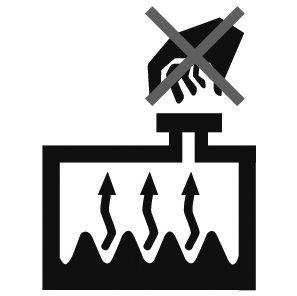

In [73]:
from IPython.display import display

# 페이지 끝부분의 제목과 문장을 확인합니다.
nonempty_lines = [
    line.strip()
    for line in pdf52_text.splitlines()
    if line.strip()
]
print("PDF 52쪽 마지막 글:")
for line in nonempty_lines[-12:]:
    print(line)

# 작은 복사본을 화면에 표시해 이미지가 어느 설명과 연결되는지 살펴봅니다.
image_preview = page52.images[0].image.copy()
image_preview.thumbnail((500, 500))

print("\n이미지:", page52.images[0].name, page52.images[0].image.size)
display(image_preview)

In [74]:
# 각 주제가 시작되는 위치를 찾습니다.
engine_start = pdf52_text.find("엔진룸 점검")
tire_start = pdf52_text.find(
    "규격 타이어 장착 및 타이어 공기압 수시 점검"
)
cluster_start = pdf52_text.find("클러스터 및 페달류 점검")

print("주제 제목을 찾았나요?:", engine_start >= 0, tire_start >= 0, cluster_start >= 0)

# 엔진룸 점검 부분과 타이어 점검 부분을 나눕니다.
engine_room_raw = pdf52_text[engine_start:tire_start].strip()
tire_check_raw = pdf52_text[tire_start:cluster_start].strip()

print("\n--- 엔진룸 점검 원문 ---")
print(engine_room_raw)

print("\n--- 타이어 점검 원문 ---")
print(tire_check_raw)

주제 제목을 찾았나요?: True True True

--- 엔진룸 점검 원문 ---
엔진룸 점검
•브레이크액 점검
 브레이크액 리저버 탱크 내의 브레이크액 양이 규정범위 내에 있는지 확인하십시오.
 브레이크액이 부족하거나 급격히 감소되었다면 당사 직영 하이테크센터나 블루핸즈에서 점검
 을 받으십시오.
•냉각수 누수 점검
 라디에이터와 호스에서 냉각수가 새지 않는지 점검하십시오.
•벨트류 점검
 정기 점검 주기표의 기준에 따라 당사 직영 하이테크센터나 블루핸즈에서 점검을 받으십시오.
•냉각수량 점검
 냉각수 보조 탱크의 냉각수량이 최대선과 최소선 사이에 있는지 점검하고, 부족하면 부동액과
 증류수를 섞어 보충하십시오.



냉각수의 점검은 반드시 엔진이 차가울 때 실시하십시오. 온도에 따라 냉각수의 양이 달라질 수 있
으며, 수온이 높을 때 보조 탱크의 캡을 열면 냉각수가 분출되어 화상을 입을 수 있습니다.

--- 타이어 점검 원문 ---
규격 타이어 장착 및 타이어 공기압 수시 점검
•적합한 규격의 타이어를 사용하십시오.
•타이어의 접지 상태를 수시로 확인하십시오.
•적정 타이어 공기압을 항상 유지하십시오.
•장거리 주행 또는 고속 주행을 하기 전에 타이어 공기압을 반드시 점검하십시오. 공기압이 부족
 하면 고속 주행 중 스탠딩 웨이브 현상이 일어나 타이어가 파열될 수 있고, 이는 차량 전복 등의
 사고로 이어질 수 있습니다.



스탠딩 웨이브(Standing Wave) 현상
타이어 공기압이 부족한 상태에서 고속으로 주행하면 타이어에 물결처럼 주름이 접히는 현상을
말합니다. 이 현상이 계속되면 타이어가 단시간에 파열됩니다.


In [75]:
# 엔진룸 점검 글을 읽기 쉬운 검색용 글로 정리합니다.
engine_room_content = """엔진룸 점검
• 브레이크액 점검: 브레이크액 리저버 탱크의 양이 규정 범위 안에 있는지 확인하십시오. 부족하거나 급격히 줄었다면 정비소에서 점검을 받으십시오.
• 냉각수 누수 점검: 라디에이터와 호스에서 냉각수가 새지 않는지 확인하십시오.
• 벨트류 점검: 정기 점검 주기표에 따라 점검을 받으십시오.
• 냉각수량 점검: 냉각수 보조 탱크의 양이 최대선과 최소선 사이인지 확인하고, 부족하면 부동액과 증류수를 섞어 보충하십시오.
냉각수는 엔진이 차가울 때 점검하십시오. 수온이 높을 때 보조 탱크 캡을 열면 냉각수가 분출되어 화상을 입을 수 있습니다.
[그림 설명] I2.jpg: 냉각수 점검 주의사항과 함께 배치된 그림으로, 뜨거운 용기 위로 손을 대지 말라는 X 표시가 있습니다."""

# 타이어 점검과 스탠딩 웨이브 설명은 별도로 정리합니다.
tire_check_content = """규격 타이어 장착 및 타이어 공기압 수시 점검
• 적합한 규격의 타이어를 사용하십시오.
• 타이어의 접지 상태를 수시로 확인하십시오.
• 적정 타이어 공기압을 항상 유지하십시오.
• 장거리 또는 고속 주행 전에는 타이어 공기압을 반드시 점검하십시오. 공기압이 부족하면 고속 주행 중 타이어가 파열되어 차량 전복 등의 사고로 이어질 수 있습니다.
스탠딩 웨이브(Standing Wave) 현상: 타이어 공기압이 부족한 상태에서 고속으로 주행할 때 타이어에 물결처럼 주름이 접히는 현상입니다. 이 현상이 계속되면 타이어가 단시간에 파열됩니다."""

# I2 이미지는 저장하지 않고, 기존 PDF 안의 이미지 정보만 기록합니다.
engine_room_image = page52.images[0]

engine_room_record = {
    "content": engine_room_content,
    "raw_text": engine_room_raw,
    "metadata": {
        "pdf_page_number": 52,
        "manual_page_number": 47,
        "content_type": "figure_with_text",
    },
    "image_parts": [
        {
            "name": engine_room_image.name,
            "size": engine_room_image.image.size,
            "description": "냉각수 점검 주의사항과 함께 배치된 그림으로, 뜨거운 용기 위로 손을 대지 말라는 X 표시가 있다.",
        }
    ],
}

tire_check_record = {
    "content": tire_check_content,
    "raw_text": tire_check_raw,
    "metadata": {
        "pdf_page_number": 52,
        "manual_page_number": 47,
        "content_type": "instruction_text",
    },
    "image_parts": [],
}

# 두 기록이 의도한 대로 나뉘었는지 요약합니다.
for record in (engine_room_record, tire_check_record):
    print(
        "종류:", record["metadata"]["content_type"],
        "| PDF 쪽:", record["metadata"]["pdf_page_number"],
        "| 원본 글자 수:", len(record["raw_text"]),
        "| 검색용 글자 수:", len(record["content"]),
        "| 이미지 수:", len(record["image_parts"]),
    )
    print(record["content"], "\n")

종류: figure_with_text | PDF 쪽: 52 | 원본 글자 수: 409 | 검색용 글자 수: 382 | 이미지 수: 1
엔진룸 점검
• 브레이크액 점검: 브레이크액 리저버 탱크의 양이 규정 범위 안에 있는지 확인하십시오. 부족하거나 급격히 줄었다면 정비소에서 점검을 받으십시오.
• 냉각수 누수 점검: 라디에이터와 호스에서 냉각수가 새지 않는지 확인하십시오.
• 벨트류 점검: 정기 점검 주기표에 따라 점검을 받으십시오.
• 냉각수량 점검: 냉각수 보조 탱크의 양이 최대선과 최소선 사이인지 확인하고, 부족하면 부동액과 증류수를 섞어 보충하십시오.
냉각수는 엔진이 차가울 때 점검하십시오. 수온이 높을 때 보조 탱크 캡을 열면 냉각수가 분출되어 화상을 입을 수 있습니다.
[그림 설명] I2.jpg: 냉각수 점검 주의사항과 함께 배치된 그림으로, 뜨거운 용기 위로 손을 대지 말라는 X 표시가 있습니다. 

종류: instruction_text | PDF 쪽: 52 | 원본 글자 수: 334 | 검색용 글자 수: 301 | 이미지 수: 0
규격 타이어 장착 및 타이어 공기압 수시 점검
• 적합한 규격의 타이어를 사용하십시오.
• 타이어의 접지 상태를 수시로 확인하십시오.
• 적정 타이어 공기압을 항상 유지하십시오.
• 장거리 또는 고속 주행 전에는 타이어 공기압을 반드시 점검하십시오. 공기압이 부족하면 고속 주행 중 타이어가 파열되어 차량 전복 등의 사고로 이어질 수 있습니다.
스탠딩 웨이브(Standing Wave) 현상: 타이어 공기압이 부족한 상태에서 고속으로 주행할 때 타이어에 물결처럼 주름이 접히는 현상입니다. 이 현상이 계속되면 타이어가 단시간에 파열됩니다. 



In [76]:
engine_room_record["content"] = """엔진룸 점검
• 브레이크액 점검
브레이크액 리저버 탱크 내의 브레이크액 양이 규정범위 내에 있는지 확인하십시오. 브레이크액이 부족하거나 급격히 감소되었다면 당사 직영 하이테크센터나 블루핸즈에서 점검을 받으십시오.
• 냉각수 누수 점검
라디에이터와 호스에서 냉각수가 새지 않는지 점검하십시오.
• 벨트류 점검
정기 점검 주기표의 기준에 따라 당사 직영 하이테크센터나 블루핸즈에서 점검을 받으십시오.
• 냉각수량 점검
냉각수 보조 탱크의 냉각수량이 최대선과 최소선 사이에 있는지 점검하고, 부족하면 부동액과 증류수를 섞어 보충하십시오.
냉각수의 점검은 반드시 엔진이 차가울 때 실시하십시오. 온도에 따라 냉각수의 양이 달라질 수 있으며, 수온이 높을 때 보조 탱크의 캡을 열면 냉각수가 분출되어 화상을 입을 수 있습니다.
[그림 설명] I2.jpg: 증기가 올라오는 용기 위로 손이 향해 있고 X 표시가 있다. 냉각수가 뜨거울 때 보조 탱크 캡을 열지 말라는 주의사항을 보여준다."""

tire_check_record["content"] = """규격 타이어 장착 및 타이어 공기압 수시 점검
• 적합한 규격의 타이어를 사용하십시오.
• 타이어의 접지 상태를 수시로 확인하십시오.
• 적정 타이어 공기압을 항상 유지하십시오.
• 장거리 주행 또는 고속 주행을 하기 전에 타이어 공기압을 반드시 점검하십시오. 공기압이 부족하면 고속 주행 중 스탠딩 웨이브 현상이 일어나 타이어가 파열될 수 있고, 이는 차량 전복 등의 사고로 이어질 수 있습니다.
스탠딩 웨이브(Standing Wave) 현상: 타이어 공기압이 부족한 상태에서 고속으로 주행하면 타이어에 물결처럼 주름이 접히는 현상을 말합니다. 이 현상이 계속되면 타이어가 단시간에 파열됩니다."""

print("엔진룸 검색용 글:")
print(engine_room_record["content"])
print("\n타이어 검색용 글:")
print(tire_check_record["content"])

엔진룸 검색용 글:
엔진룸 점검
• 브레이크액 점검
브레이크액 리저버 탱크 내의 브레이크액 양이 규정범위 내에 있는지 확인하십시오. 브레이크액이 부족하거나 급격히 감소되었다면 당사 직영 하이테크센터나 블루핸즈에서 점검을 받으십시오.
• 냉각수 누수 점검
라디에이터와 호스에서 냉각수가 새지 않는지 점검하십시오.
• 벨트류 점검
정기 점검 주기표의 기준에 따라 당사 직영 하이테크센터나 블루핸즈에서 점검을 받으십시오.
• 냉각수량 점검
냉각수 보조 탱크의 냉각수량이 최대선과 최소선 사이에 있는지 점검하고, 부족하면 부동액과 증류수를 섞어 보충하십시오.
냉각수의 점검은 반드시 엔진이 차가울 때 실시하십시오. 온도에 따라 냉각수의 양이 달라질 수 있으며, 수온이 높을 때 보조 탱크의 캡을 열면 냉각수가 분출되어 화상을 입을 수 있습니다.
[그림 설명] I2.jpg: 증기가 올라오는 용기 위로 손이 향해 있고 X 표시가 있다. 냉각수가 뜨거울 때 보조 탱크 캡을 열지 말라는 주의사항을 보여준다.

타이어 검색용 글:
규격 타이어 장착 및 타이어 공기압 수시 점검
• 적합한 규격의 타이어를 사용하십시오.
• 타이어의 접지 상태를 수시로 확인하십시오.
• 적정 타이어 공기압을 항상 유지하십시오.
• 장거리 주행 또는 고속 주행을 하기 전에 타이어 공기압을 반드시 점검하십시오. 공기압이 부족하면 고속 주행 중 스탠딩 웨이브 현상이 일어나 타이어가 파열될 수 있고, 이는 차량 전복 등의 사고로 이어질 수 있습니다.
스탠딩 웨이브(Standing Wave) 현상: 타이어 공기압이 부족한 상태에서 고속으로 주행하면 타이어에 물결처럼 주름이 접히는 현상을 말합니다. 이 현상이 계속되면 타이어가 단시간에 파열됩니다.


In [77]:
# 서로 다른 자료 유형의 후보 기록을 하나의 목록으로 모읍니다.
sample_records = list(overview_records)
sample_records.extend(normalized_records)
sample_records.extend([
    pdf74_candidate_chunk,
    daily_check_record,
    engine_room_record,
    tire_check_record,
])

required_fields = {"content", "raw_text", "metadata", "image_parts"}
type_counts = {}

# 각 기록의 종류와 공통 필드가 있는지 확인합니다.
for number, record in enumerate(sample_records, start=1):
    metadata = record.get("metadata", {})
    content_type = metadata.get("content_type")
    type_counts[content_type] = type_counts.get(content_type, 0) + 1
    missing_fields = required_fields - record.keys()

    print(
        number,
        "| 종류:", content_type,
        "| PDF 쪽:", metadata.get("pdf_page_number"),
        "| 이미지 수:", len(record.get("image_parts", [])),
        "| 빠진 항목:", sorted(missing_fields),
    )

print("\n후보 기록 수:", len(sample_records))
print("유형별 개수:", type_counts)

1 | 종류: vehicle_overview_navigation | PDF 쪽: 30 | 이미지 수: 1 | 빠진 항목: []
2 | 종류: vehicle_overview_navigation | PDF 쪽: 31 | 이미지 수: 1 | 빠진 항목: []
3 | 종류: vehicle_overview_navigation | PDF 쪽: 33 | 이미지 수: 1 | 빠진 항목: []
4 | 종류: vehicle_overview_navigation | PDF 쪽: 34 | 이미지 수: 1 | 빠진 항목: []
5 | 종류: vehicle_overview_navigation | PDF 쪽: 35 | 이미지 수: 1 | 빠진 항목: []
6 | 종류: table_with_images | PDF 쪽: 44 | 이미지 수: 2 | 빠진 항목: []
7 | 종류: figure_with_text | PDF 쪽: 45 | 이미지 수: 1 | 빠진 항목: []
8 | 종류: figure_with_text | PDF 쪽: 74 | 이미지 수: 2 | 빠진 항목: []
9 | 종류: instruction_text | PDF 쪽: 51 | 이미지 수: 0 | 빠진 항목: []
10 | 종류: figure_with_text | PDF 쪽: 52 | 이미지 수: 1 | 빠진 항목: []
11 | 종류: instruction_text | PDF 쪽: 52 | 이미지 수: 0 | 빠진 항목: []

후보 기록 수: 11
유형별 개수: {'vehicle_overview_navigation': 5, 'table_with_images': 1, 'figure_with_text': 3, 'instruction_text': 2}


In [78]:
# PDF 52쪽에서 클러스터 점검 제목 이후만 가져옵니다.
cluster_start = pdf52_text.find("클러스터 및 페달류 점검")
cluster_start_text = pdf52_text[cluster_start:].strip()

# PDF 53쪽의 글도 읽습니다.
page53 = reader.pages[52]
pdf53_text = page53.extract_text(extraction_mode="layout")

print("--- PDF 52쪽의 클러스터 점검 시작 부분 ---")
print(cluster_start_text)

print("\n--- PDF 53쪽 글 앞부분 ---")
print(pdf53_text[:1000])

print("\nPDF 53쪽 글자 수:", len(pdf53_text))
print("PDF 53쪽 이미지 개수:", len(page53.images))

--- PDF 52쪽의 클러스터 점검 시작 부분 ---
클러스터 및 페달류 점검
•클러스터 점검
47

--- PDF 53쪽 글 앞부분 ---
                                                              2


 클러스터에 표시된 각종 정보의 이상 유무를 확인하고 연료량이 충분한지 점검하십시오.
•페달류 점검
 페달을 가볍게 밟아 이상 유무를 확인하십시오. 평소 사용할 때보다 간극이 더 길거나 짧아지면
 즉시 당사 직영 하이테크센터나 블루핸즈에서 점검을 받으십시오.

올바른 운전 자세
올바른 운전 자세가 되도록 운전석과 스티어링 휠을 조절하십시오.
바람직한 운전 자세는 좌석에 깊숙이 앉아 브레이크 페달을 끝까지 밟았을 때 무릎이 약간 굽혀지
고, 손목이 스티어링 휠의 가장 먼 곳에 닿아야 합니다. 또한, 헤드레스트의 높이가 조절되는 차량
인 경우는 운전자의 귀 상단이 헤드레스트 중심에 올 수 있도록 헤드레스트를 조절하십시오.

좌석, 스티어링 휠, 미러 조정
•좌석, 스티어링 휠, 미러는 출발 전에 조절하시고 주행 중에 절대로 조작하지 마십시오.
•내외측의 미러를 조정하여 충분한 시야를 확보하십시오.
•모든 게이지 및 경고등을 확인하십시오.
•파킹 브레이크를 풀고 브레이크 경고등이 꺼지는지 확인하십시오.
•차 주위에 사람이나 물체 등이 없는지 확인하십시오.



•운전할 때 하이힐 등 운전하기 불편한 신발을 신지 마십시오. 가속 페달, 브레이크 페달 등의 조
 작 능력이 저하되어 사고의 원인이 됩니다.
•파킹 브레이크를 풀 때는 차량이 움직일 수 있으므로 반드시 브레이크 페달을 확실히 밟으십시
 오.


운전석 주변 점검
•운전석 주변은 항상 깨끗하게 유지하십시오. 빈 깡통 등이 페달 밑으로 굴러 들어갈 경우 페달
 조작이 불가능하게 되어 매우 위험합니다.
•바닥 매트는 페달의 움직임을 방해하지 않는 것으로 너무 두껍지 않으면서 바닥에 고정되는 제
 품이어야 합니다.
•차 안에는 화물을 좌석 높이 이상으로 적재

In [79]:
# PDF 53쪽에서 다음 주제 제목 전까지가 클러스터·페달 점검의 이어지는 부분입니다.
cluster_page53_raw = pdf53_text.split("올바른 운전 자세", 1)[0].strip()

cluster_pedal_content = """클러스터 및 페달류 점검
• 클러스터 점검: 클러스터에 표시된 각종 정보의 이상 유무를 확인하고 연료량이 충분한지 점검하십시오.
• 페달류 점검: 페달을 가볍게 밟아 이상 유무를 확인하십시오. 평소 사용할 때보다 간극이 더 길거나 짧아지면 즉시 당사 직영 하이테크센터나 블루핸즈에서 점검을 받으십시오."""

cluster_pedal_record = {
    "content": cluster_pedal_content,
    "raw_text": cluster_start_text + "\n\n" + cluster_page53_raw,
    "metadata": {
        "pdf_page_number": 52,
        "continued_on_pdf_page": 53,
        "manual_page_number": 47,
        "continuation_manual_page_number": 48,
        "content_type": "instruction_text",
    },
    "image_parts": [],
}

print("기록 종류:", cluster_pedal_record["metadata"]["content_type"])
print("원본 글자 수:", len(cluster_pedal_record["raw_text"]))
print("검색용 글자 수:", len(cluster_pedal_record["content"]))
print("이미지 개수:", len(cluster_pedal_record["image_parts"]))
print("\n검색용 글:")
print(cluster_pedal_record["content"])

기록 종류: instruction_text
원본 글자 수: 175
검색용 글자 수: 168
이미지 개수: 0

검색용 글:
클러스터 및 페달류 점검
• 클러스터 점검: 클러스터에 표시된 각종 정보의 이상 유무를 확인하고 연료량이 충분한지 점검하십시오.
• 페달류 점검: 페달을 가볍게 밟아 이상 유무를 확인하십시오. 평소 사용할 때보다 간극이 더 길거나 짧아지면 즉시 당사 직영 하이테크센터나 블루핸즈에서 점검을 받으십시오.


In [80]:
# PDF 53쪽에서 "올바른 운전 자세"에 해당하는 원문만 잘라냅니다.
posture_raw = (
    "올바른 운전 자세"
    + pdf53_text.split("올바른 운전 자세", 1)[1]
        .split("좌석, 스티어링 휠, 미러 조정", 1)[0]
)

# 줄바꿈으로 끊긴 문장을 읽기 좋게 정리한 검색용 글입니다.
posture_content = """올바른 운전 자세
올바른 운전 자세가 되도록 운전석과 스티어링 휠을 조절하십시오. 바람직한 운전 자세는 좌석에 깊숙이 앉아 브레이크 페달을 끝까지 밟았을 때 무릎이 약간 굽혀지고, 손목이 스티어링 휠의 가장 먼 곳에 닿아야 합니다. 또한 헤드레스트 높이가 조절되는 차량은 운전자의 귀 상단이 헤드레스트 중심에 오도록 조절하십시오."""

driving_posture_record = {
    "content": posture_content,
    "raw_text": posture_raw.strip(),
    "metadata": {
        "pdf_page_number": 53,
        "manual_page_number": 48,
        "content_type": "instruction_text",
    },
    "image_parts": [],
}

print("기록 종류:", driving_posture_record["metadata"]["content_type"])
print("원본 글자 수:", len(driving_posture_record["raw_text"]))
print("이미지 개수:", len(driving_posture_record["image_parts"]))
print("\n검색용 글:")
print(driving_posture_record["content"])

기록 종류: instruction_text
원본 글자 수: 203
이미지 개수: 0

검색용 글:
올바른 운전 자세
올바른 운전 자세가 되도록 운전석과 스티어링 휠을 조절하십시오. 바람직한 운전 자세는 좌석에 깊숙이 앉아 브레이크 페달을 끝까지 밟았을 때 무릎이 약간 굽혀지고, 손목이 스티어링 휠의 가장 먼 곳에 닿아야 합니다. 또한 헤드레스트 높이가 조절되는 차량은 운전자의 귀 상단이 헤드레스트 중심에 오도록 조절하십시오.


In [82]:
# PDF 53쪽에서 해당 제목부터 다음 제목 전까지 원문을 가져옵니다.
adjustment_title = "좌석, 스티어링 휠, 미러 조정"
driver_area_title = "운전석 주변 점검"

adjustment_raw = (
    adjustment_title
    + pdf53_text.split(adjustment_title, 1)[1]
        .split(driver_area_title, 1)[0]
)

# 출발 전 조정 항목과 관련 주의사항을 제목 아래에 정리합니다.
adjustment_content = """좌석, 스티어링 휠, 미러 조정
• 좌석, 스티어링 휠, 미러는 출발 전에 조절하고 주행 중에는 조작하지 마십시오.
• 내외측의 미러를 조정하여 충분한 시야를 확보하십시오.
• 모든 게이지 및 경고등을 확인하십시오.
• 파킹 브레이크를 풀고 브레이크 경고등이 꺼지는지 확인하십시오.
• 차 주위에 사람이나 물체 등이 없는지 확인하십시오.
• 운전할 때 하이힐 등 운전하기 불편한 신발을 신지 마십시오. 가속 페달과 브레이크 페달 등의 조작 능력이 저하되어 사고의 원인이 됩니다.
• 파킹 브레이크를 풀 때는 차량이 움직일 수 있으므로 반드시 브레이크 페달을 확실히 밟으십시오."""

driver_adjustment_record = {
    "content": adjustment_content,
    "raw_text": adjustment_raw.strip(),
    "metadata": {
        "pdf_page_number": 53,
        "manual_page_number": 48,
        "content_type": "instruction_text",
    },
    "image_parts": [],
}

print("기록 종류:", driver_adjustment_record["metadata"]["content_type"])
print("원본 글자 수:", len(driver_adjustment_record["raw_text"]))
print("이미지 개수:", len(driver_adjustment_record["image_parts"]))
print("\n검색용 글:")
print(driver_adjustment_record["content"])

기록 종류: instruction_text
원본 글자 수: 326
이미지 개수: 0

검색용 글:
좌석, 스티어링 휠, 미러 조정
• 좌석, 스티어링 휠, 미러는 출발 전에 조절하고 주행 중에는 조작하지 마십시오.
• 내외측의 미러를 조정하여 충분한 시야를 확보하십시오.
• 모든 게이지 및 경고등을 확인하십시오.
• 파킹 브레이크를 풀고 브레이크 경고등이 꺼지는지 확인하십시오.
• 차 주위에 사람이나 물체 등이 없는지 확인하십시오.
• 운전할 때 하이힐 등 운전하기 불편한 신발을 신지 마십시오. 가속 페달과 브레이크 페달 등의 조작 능력이 저하되어 사고의 원인이 됩니다.
• 파킹 브레이크를 풀 때는 차량이 움직일 수 있으므로 반드시 브레이크 페달을 확실히 밟으십시오.


In [83]:
driver_adjustment_record["content"] = """좌석, 스티어링 휠, 미러 조정
• 좌석, 스티어링 휠, 미러는 출발 전에 조절하시고 주행 중에 절대로 조작하지 마십시오.
• 내외측의 미러를 조정하여 충분한 시야를 확보하십시오.
• 모든 게이지 및 경고등을 확인하십시오.
• 파킹 브레이크를 풀고 브레이크 경고등이 꺼지는지 확인하십시오.
• 차 주위에 사람이나 물체 등이 없는지 확인하십시오.
• 운전할 때 하이힐 등 운전하기 불편한 신발을 신지 마십시오. 가속 페달, 브레이크 페달 등의 조작 능력이 저하되어 사고의 원인이 됩니다.
• 파킹 브레이크를 풀 때는 차량이 움직일 수 있으므로 반드시 브레이크 페달을 확실히 밟으십시오."""

print(driver_adjustment_record["content"])

좌석, 스티어링 휠, 미러 조정
• 좌석, 스티어링 휠, 미러는 출발 전에 조절하시고 주행 중에 절대로 조작하지 마십시오.
• 내외측의 미러를 조정하여 충분한 시야를 확보하십시오.
• 모든 게이지 및 경고등을 확인하십시오.
• 파킹 브레이크를 풀고 브레이크 경고등이 꺼지는지 확인하십시오.
• 차 주위에 사람이나 물체 등이 없는지 확인하십시오.
• 운전할 때 하이힐 등 운전하기 불편한 신발을 신지 마십시오. 가속 페달, 브레이크 페달 등의 조작 능력이 저하되어 사고의 원인이 됩니다.
• 파킹 브레이크를 풀 때는 차량이 움직일 수 있으므로 반드시 브레이크 페달을 확실히 밟으십시오.


In [84]:
# PDF 53쪽에서 운전석 주변 점검 제목부터 원문을 가져옵니다.
driver_area_title = "운전석 주변 점검"
driver_area_raw = (
    driver_area_title
    + pdf53_text.split(driver_area_title, 1)[1]
)

driver_area_content = """운전석 주변 점검
• 운전석 주변은 항상 깨끗하게 유지하십시오. 빈 깡통 등이 페달 밑으로 굴러 들어가면 페달 조작이 불가능해 매우 위험합니다.
• 바닥 매트는 페달 움직임을 방해하지 않아야 하며, 너무 두껍지 않고 바닥에 고정되는 제품이어야 합니다.
• 차 안에는 화물을 좌석 높이 이상으로 적재하지 마십시오."""

driver_area_record = {
    "content": driver_area_content,
    "raw_text": driver_area_raw.strip(),
    "metadata": {
        "pdf_page_number": 53,
        "manual_page_number": 48,
        "content_type": "instruction_text",
    },
    "image_parts": [],
}

print("기록 종류:", driver_area_record["metadata"]["content_type"])
print("원본 글자 수:", len(driver_area_record["raw_text"]))
print("이미지 개수:", len(driver_area_record["image_parts"]))
print("\n검색용 글:")
print(driver_area_record["content"])

기록 종류: instruction_text
원본 글자 수: 256
이미지 개수: 0

검색용 글:
운전석 주변 점검
• 운전석 주변은 항상 깨끗하게 유지하십시오. 빈 깡통 등이 페달 밑으로 굴러 들어가면 페달 조작이 불가능해 매우 위험합니다.
• 바닥 매트는 페달 움직임을 방해하지 않아야 하며, 너무 두껍지 않고 바닥에 고정되는 제품이어야 합니다.
• 차 안에는 화물을 좌석 높이 이상으로 적재하지 마십시오.


In [85]:
driver_area_record["content"] = """운전석 주변 점검
• 운전석 주변은 항상 깨끗하게 유지하십시오. 빈 깡통 등이 페달 밑으로 굴러 들어갈 경우 페달 조작이 불가능하게 되어 매우 위험합니다.
• 바닥 매트는 페달의 움직임을 방해하지 않는 것으로 너무 두껍지 않으면서 바닥에 고정되는 제품이어야 합니다.
• 차 안에는 화물을 좌석 높이 이상으로 적재하지 마십시오."""

print(driver_area_record["content"])

운전석 주변 점검
• 운전석 주변은 항상 깨끗하게 유지하십시오. 빈 깡통 등이 페달 밑으로 굴러 들어갈 경우 페달 조작이 불가능하게 되어 매우 위험합니다.
• 바닥 매트는 페달의 움직임을 방해하지 않는 것으로 너무 두껍지 않으면서 바닥에 고정되는 제품이어야 합니다.
• 차 안에는 화물을 좌석 높이 이상으로 적재하지 마십시오.


In [86]:
# 지금까지 만든 기록을 한 목록으로 모읍니다.
sample_records = list(overview_records)
sample_records.extend(normalized_records)
sample_records.extend([
    pdf74_candidate_chunk,
    daily_check_record,
    engine_room_record,
    tire_check_record,
    cluster_pedal_record,
    driving_posture_record,
    driver_adjustment_record,
    driver_area_record,
])

required_fields = {"content", "raw_text", "metadata", "image_parts"}
type_counts = {}
total_images = 0

# 기록별로 공통 항목이 있는지 확인하고 유형과 이미지 수를 셉니다.
for number, record in enumerate(sample_records, start=1):
    metadata = record.get("metadata", {})
    content_type = metadata.get("content_type")
    image_count = len(record.get("image_parts", []))

    type_counts[content_type] = type_counts.get(content_type, 0) + 1
    total_images += image_count

    missing_fields = required_fields - record.keys()
    print(
        number,
        "| PDF 쪽:", metadata.get("pdf_page_number"),
        "| 종류:", content_type,
        "| 이미지:", image_count,
        "| 빠진 항목:", sorted(missing_fields),
    )

print("\n후보 기록 수:", len(sample_records))
print("유형별 개수:", type_counts)
print("연결된 이미지 수:", total_images)

1 | PDF 쪽: 30 | 종류: vehicle_overview_navigation | 이미지: 1 | 빠진 항목: []
2 | PDF 쪽: 31 | 종류: vehicle_overview_navigation | 이미지: 1 | 빠진 항목: []
3 | PDF 쪽: 33 | 종류: vehicle_overview_navigation | 이미지: 1 | 빠진 항목: []
4 | PDF 쪽: 34 | 종류: vehicle_overview_navigation | 이미지: 1 | 빠진 항목: []
5 | PDF 쪽: 35 | 종류: vehicle_overview_navigation | 이미지: 1 | 빠진 항목: []
6 | PDF 쪽: 44 | 종류: table_with_images | 이미지: 2 | 빠진 항목: []
7 | PDF 쪽: 45 | 종류: figure_with_text | 이미지: 1 | 빠진 항목: []
8 | PDF 쪽: 74 | 종류: figure_with_text | 이미지: 2 | 빠진 항목: []
9 | PDF 쪽: 51 | 종류: instruction_text | 이미지: 0 | 빠진 항목: []
10 | PDF 쪽: 52 | 종류: figure_with_text | 이미지: 1 | 빠진 항목: []
11 | PDF 쪽: 52 | 종류: instruction_text | 이미지: 0 | 빠진 항목: []
12 | PDF 쪽: 52 | 종류: instruction_text | 이미지: 0 | 빠진 항목: []
13 | PDF 쪽: 53 | 종류: instruction_text | 이미지: 0 | 빠진 항목: []
14 | PDF 쪽: 53 | 종류: instruction_text | 이미지: 0 | 빠진 항목: []
15 | PDF 쪽: 53 | 종류: instruction_text | 이미지: 0 | 빠진 항목: []

후보 기록 수: 15
유형별 개수: {'vehicle_overview_navigation': 5, 'table_with_

In [87]:
def make_chunk_record(content, raw_text, metadata, image_parts=None):
    """검색용 글과 원문, 출처, 이미지 정보를 하나의 청크 기록으로 묶습니다.

    글만 있는 청크라면 image_parts를 생략하거나 빈 목록으로 둘 수 있습니다.
    """
    # 이미지가 없는 기록도 항상 같은 구조를 갖도록 빈 목록을 사용합니다.
    if image_parts is None:
        image_parts = []

    return {
        "content": content,
        "raw_text": raw_text,
        "metadata": metadata,
        "image_parts": image_parts,
    }


# 이미 만든 일상 점검 기록의 내용을 함수에 넣어 같은 형식으로 만듭니다.
daily_check_record_example = make_chunk_record(
    content=daily_check_record["content"],
    raw_text=daily_check_record["raw_text"],
    metadata=daily_check_record["metadata"],
    image_parts=daily_check_record["image_parts"],
)

print("기록 항목:", list(daily_check_record_example.keys()))
print("출처 정보:", daily_check_record_example["metadata"])
print("이미지 개수:", len(daily_check_record_example["image_parts"]))

기록 항목: ['content', 'raw_text', 'metadata', 'image_parts']
출처 정보: {'pdf_page_number': 51, 'manual_page_number': 46, 'content_type': 'instruction_text'}
이미지 개수: 0


In [88]:
import importlib.util

# 로컬에서 임베딩 모델을 실행할 때 자주 사용하는 라이브러리입니다.
libraries = [
    ("Sentence Transformers", "sentence_transformers"),
    ("Transformers", "transformers"),
    ("PyTorch", "torch"),
    ("FastEmbed", "fastembed"),
]

for display_name, module_name in libraries:
    is_installed = importlib.util.find_spec(module_name) is not None
    status = "설치됨" if is_installed else "설치되지 않음"
    print(f"{display_name}: {status}")

Sentence Transformers: 설치되지 않음
Transformers: 설치되지 않음
PyTorch: 설치되지 않음
FastEmbed: 설치되지 않음
